# Assignment 08 - NLP Fundamentals & Vector Embeddings

### Due: Monday, Mar 23, before class

Name(s): Chang Min Bark<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References



In [1]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.52.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.9.0.47.45
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.37.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cf

In [2]:
import sys
import os
import time
from enum import Enum
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [3]:
from IPython.display import HTML, display

css_styles = """
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>
"""

display(HTML(css_styles))

In [4]:
def show_todo(todo_text):
    display(HTML(f"""
    <div class="todo-box">
    <h2>TODO: {todo_text}</h2>
    </div>
    """))

def show_note(note_text):
    display(HTML(f"""
    <div class="note-box">
    <h2>NOTE:</h2>
    <h4>{note_text}</h4>
    </div>
    """))

def show_warning(warning_text):
    display(HTML(f"""
    <div class="warning-box">
    <h2>WARNING:</h2>
    <h3>{warning_text}</h3>
    </div>
    """))

def show_section(section_text = ""):
    display(HTML(f"""
    <div class="section-box">
    <h1>{section_text}</h1>
    </div>
    """))

In [5]:
show_todo("Set Run Configuration")

# **Notebook Run Configuration**

As most of you have already discovered, you will frequently need to re-run your notebooks from scratch. As our models and data become larger and more complex, code cells that execute training can take a lot of time. Thus, once you have finish a cell that needs to train, you might want to just execute a few epochs, or perhaps NO epochs.

* Set the variable `RUN_TRAINING_MODE` below to one of the three enumerations, then write your code to conditionally set the number of epoch to run
* Set `DO_WANDB_LOGGING` to True when you are ready to log your results.

It's up to you to properly use these constants in your code to make it easy to rerun a notebook from scratch.

In [6]:
class RunTrainingMode(Enum):
    NONE = "NONE"
    QUICK = "QUICK"
    FULL = "FULL"

RUN_TRAINING_MODE = RunTrainingMode.FULL
DO_WANDB_LOGGING = True

# **Set up accelerator device**
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [7]:
cpu_device = torch.device("cpu")

has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: cuda


In [8]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [9]:
show_todo("Set Project Path and Install Packages")

**TODO:** You need to set `project_path` to be the root path of your project. This needs to be done regardless if whether you are running from Colab or not. I included an example that works on my machine when running locally, and setting a Drive path when running from Google Colab.

In [10]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted successfully!")

    # DONE: Replace this with your Google Drive path to your project root. Below is an example:
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

    # Confirm the project_path exists, raise an error if not
    if not os.path.exists(PROJECT_PATH):
        raise FileNotFoundError(f"Project path NOT FOUND: \"{PROJECT_PATH}\"")
    else:
        print(f"Confirmed: Project path exists at \"{PROJECT_PATH}\"")
else:
    # DONE: Replace this with your project root.
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

print(f"Project path: \"{PROJECT_PATH}\"")
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
    sys.path.append(PROJECT_PATH + "/src")

# Ensure that the current working directory is PROJECT_PATH
if os.getcwd() != PROJECT_PATH:
    print(f"Changing working directory to project path: \"{PROJECT_PATH}\"")
    os.chdir(PROJECT_PATH)
else:
    print(f"Already in the correct working directory: \"{PROJECT_PATH}\"")

Mounted at /content/drive
Drive mounted successfully!
Confirmed: Project path exists at "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Changing working directory to project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"


In [11]:
# Install any packages that are not part of the standard Google Colab environment
if IN_COLAB:
    # Install uv for fast installs (-q for quiet, -U for update)
    !pip install -qU uv
    # Install project dependencies and local code in editable mode,
    !uv pip install -e .
    print("Colab install commands are provided above; uncomment to run them.")
else:
    print("Running locally, assuming project dependencies installed in your local environment.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 116.3 MB/s eta 0:00:0000:0100:01
Using Python 3.12.12 environment at: /usr
Resolved 215 packages in 1.07s                                       
Prepared 23 packages in 2.57s                                            
Uninstalled 5 packages in 408ms
Installed 23 packages in 72ms                               
 + asttokens==3.0.1
 + async-lru==2.2.0
 - decorator==4.4.2
 + decorator==5.2.1
 + executing==2.2.1
 - ipython==7.34.0
 + ipython==9.11.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + json5==0.13.0
 + jupyter==1.1.1
 + jupyter-lsp==2.3.0
 + jupyterlab==4.5.6
 + jupyterlab-server==2.28.0
 + lantern==0.1.0 (from file:///content/drive/My%20Drive/2026%20SS/CSCI357/csci357_2026sp)
 + lightning-utilities==0.15.3
 + pure-eval==0.2.3
 + pydeck==0.9.1
 - scipy==1.16.3
 + scipy==1.13.1
 + stack-data==0.6.3
 + streamlit==1.55.0
 + torchmetrics==1.9.0
 - traitlets==5.7.1
 + traitlets==5.14.3
 - transformers==5.0.0
 + transformer

In [12]:
if IN_COLAB:
    # import os
    # os.kill(os.getpid(), 9)
    pass

In [13]:
# Once packages are installed, we can kill the kernel to force a restart. Just restart the kernel
if IN_COLAB:
    try:
        import lantern
        print(lantern.__file__)
        print("Success!")
    except Exception as e:
        print("Might need to restart your kernel.")
        # This will force the kernel to restart
        # import os
        # os.kill(os.getpid(), 9)

/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/__init__.py
Success!


In [14]:
# Turn on the "Auto-Updater"
%load_ext autoreload
%autoreload 2

In [15]:
import wandb

In [16]:
show_todo("Set W&B Configuration Variables")

# Set your identity variables for W&B!

Fill in the following variables below to ensure your data is properly logged to Weights & Biases

In [17]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

In [18]:
show_section()

# Background

## Overview

Last week you built deep CNN architectures with Batch Normalization, Residual Connections, and Global Average Pooling. You proved that engineering architectural changes in the network can make some big diffrences in outcomes, very deep networks trainable. You also graduated from scalar accuracy to confusion matrices and handled class imbalance on a real-world bankruptcy dataset. All of that work centered on **spatial** data: images with height, width, and channels.

This week marks a **major pivot**. We leave the world of pixels behind and enter the world of **words**, **sequences**, and **time series**. This is Phase 3 of the course: Natural Language Processing (NLP). Instead of images with spatial locality and translation invariance, we now face **sequential** data where **order matters** -- a fundamentally different challenge that requires fundamentally different representations.

The good news: the engineering patterns you built -- `Trainer`, `DataLoader`, W&B logging, config-driven experiments -- carry over unchanged. The data modality is new, but the methods you've been using to train your models is not.

We'll focus on text first. It'll get us through a critical part of what we need to understand before we explore transformers later in the course. How do we represent text so that a neural network can process it? Remember - all inputs into the model (as well as the model itself) must be numerical! Once we solve that, we'll motive with a common NLP task - **sentiment analysis**. Can a simple model that **averages** word representations actually classify sentiment? (Spoiler alert: YES! But with a critical limitation that will motivate everything we build in the weeks ahead.)

## 1. Why Sequences Are Different from Images

In weeks 5-7, our inputs were images: 2D grids of pixel values with **spatial locality** (nearby pixels are related) and **translation invariance** (a cat in the top-left looks the same as a cat in the bottom-right). CNNs exploit both properties -- local receptive fields capture spatial patterns, and weight sharing across positions provides translation invariance.

Text, time series, and audio are different. They have **temporal or positional dependencies** -- the order of elements carries critical information. Consider:

* *"The dog bit the man"* vs. *"The man bit the dog"* -- same words, yet entirely opposite meanings!
* *"I do not like this movie"* -- removing "not" reverses the sentiment.
* *"The stock rose sharply after the CEO announced record earnings"* -- understanding the cause requires paying **attention** words across a long span. (That word, "attention", is going to be very important in the next few weeks!)

**Motivating question:** Could we flatten a sentence into a 1D vector and feed it to an MLP model? (NOTE: Do not confuse MLP - Multi-Layer Perceptron - with NLP - Natural Language Processing!) Technically yes -- but the MLP would have no notion of which word came first, and the input dimension would vary with sentence length. Could we use a CNN? We could try 1D convolutions over words (and we will, in the Challenges), but standard CNNs cannot capture dependencies between words that are far apart in the sentence.

The data modality has changed, and with it, we need a new representation strategy. That is what this week is about.

In [ ]:
show_note("Images have spatial locality (nearby pixels are correlated). Text has positional dependencies (word order determines meaning). This fundamental difference is why we need new tools beyond CNNs for language data.")

## 2. Text as Data: The Representation Problem

Computers see numbers, not words. Before any model can process text, we need to convert words into numerical representations. Let's survey the classical approaches and understand why they are insufficient.

### One-Hot Encoding

The simplest approach: assign each word in the vocabulary a unique index, then represent it as a binary vector with a 1 at that index and 0s everywhere else. For a vocabulary of $V$ words, each word becomes a binary occurrence vector of length $V$:

For a vocabulary $V = \{ \text{"apple", "banana", "cherry"} \}$, the vectors would look like this:

"apple" = $[1, 0, 0]$<br>
"banana" = $[0, 1, 0]$<br>
"cherry": $[0, 0, 1]$<br>

**Problems:**
* **Sparse and high-dimensional**: With $V = 50{,}000$ words, each vector has 50,000 dimensions with only a single non-zero entry. This is wildly inefficient!
* **No notion of similarity**: You're completely discarding context! The distance between "king" and "queen" is the same as between "king" and "toaster" -- $\sqrt{2}$ in Euclidean distance. The representation encodes no semantic relationship whatsoever.
* **No generalization**: Learning that "excellent movie" is positive tells the model nothing about "great film" -- each word is an isolated, orthogonal symbol.

### Bag-of-Words (BoW) and TF-IDF

**Bag-of-Words** represents a document as the count of each word in the vocabulary. Given a dictionary of $V$ words, a sentence, or a paragraph (or larger) becomes a $V$-dimensional vector where entry $i$ is frequency of occurrence of word $i$ in the text being encoded This discards all word order -- "dog bites man" and "man bites dog" produce the same vector, though at least the encoding captures the fact that words in the encoded text are occurring in the same text, and that relationship could be important. 

**TF-IDF** (Term Frequency - Inverse Document Frequency) improves on raw counts by downweighting common words ("the", "is"), commonly known as **"stop words"**, and upweighting rare, discriminative words. It is still a sparse $V$-dimensional vector that ignores word order and encodes no semantic relationships.

These representations powered NLP for decades (and still work surprisingly well for some tasks), but they share a fundamental limitation: they treat words as **atomic symbols** with no relationship to each other.

In [20]:
show_note("Bag-of-Words and TF-IDF are still widely used in industry for tasks like search ranking and spam filtering. They are fast, interpretable, and work well when word order does not matter much. But for tasks where meaning depends on context and word relationships, we need something better.")

## 3. Word Embeddings: From Sparse to Dense

The breakthrough idea of word embeddings is to represent each word as a **dense, low-dimensional vector** (typically 50-300 dimensions instead of 50,000) where **geometric distance encodes semantic similarity**. Words that appear in similar contexts end up with similar vectors.

### The Distributional Hypothesis

The theoretical foundation comes from linguistics:

> *"You shall know a word by the company it keeps."* -- J.R. Firth, 1957

Words that appear in similar contexts tend to have similar meanings. "Dog" and "cat" both appear near "pet", "feed", "veterinarian". "King" and "queen" both appear near "throne", "crown", "reign". A model that learns to predict a word from its context (or vice versa) will inevitably learn vector representations that capture these relationships.

### Word2Vec (Mikolov et al., 2013)

Word2Vec operationalized the distributional hypothesis with two simple architectures:

* **Skip-gram**: Given a target word, predict its surrounding context words. For the sentence "the cat sat on the mat", with target "sat" and window size 2, the model predicts {"the", "cat", "on", "the"}.
* **CBOW (Continuous Bag of Words)**: The reverse -- given context words, predict the target word.

Both architectures are shallow neural networks (essentially a single hidden layer), but trained on massive corpora (billions of words), they produce remarkably rich vector representations.

### The Famous Analogy

The most celebrated result from Word2Vec is that the learned vectors could encode **linear relationships** between concepts:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

This means the vector from "man" to "king" (capturing the concept of "royalty") is approximately the same as the vector from "woman" to "queen". The embedding space has learned abstract relationships such as gender, tense, and geography purely from word co-occurrence statistics.

### Pretrained Embeddings: Transfer Learning for Words

Just as you used a pretrained ResNet in hw07 to transfer visual features learned on ImageNet to CIFAR-10, we can use **pretrained word embeddings** -- vectors trained on massive text corpora -- and transfer that linguistic knowledge to our specific task.

The most widely used pretrained embeddings include:
* **GloVe** (Pennington et al., 2014): Trained on Wikipedia + Gigaword (6B tokens). Available in 50, 100, 200, and 300 dimensions.
* **fastText** (Bojanowski et al., 2017): Extends Word2Vec by learning subword embeddings, so it can generate vectors for out-of-vocabulary words.

Using pretrained embeddings is the NLP analog of using a pretrained CNN backbone -- someone else did the expensive training on a massive dataset, and you benefit from the learned representations.

In [21]:
show_note("The jump from one-hot encoding to dense embeddings is one of the most important conceptual leaps in NLP. It is directly analogous to the jump from raw pixels to learned CNN features -- instead of treating each input as an isolated symbol, we learn a continuous representation where geometry encodes meaning.")

## 4. `nn.Embedding` in PyTorch

Let's explore how an embedding works. PyTorch provides `nn.Embedding` -- a **learnable lookup table** that maps integer indices (such as word identifiers) to dense, continuous vectors. This is the fundamental building block for all neural NLP models, including LLMs.

Embeddings were a huge milestone toward Large Language Models (LLMs) - the models that are so prevalent through AI today. Before embeddings, we would have to perform massive matrix multiplications against a one-hot vector - something that woudl be ridiculously expensive due to the size required for any realistic vocabulary, not to mention computationally wasteful since most operations would be multiplied by zero! Instead, `nn.Embedding` simply "grabs" the row corresponding to the index you provide.

**Key Concept:** Just as Global Average Pooling from last week compresses a 3D (n c * 3x3 filters) feature map into a semantic vector, Embeddings map discrete tokens into a continuous, lower-dimensional space where "meaning" is represented by distance.
### How It Works

An `nn.Embedding(num_embeddings, embedding_dim)` stores a weight matrix of shape $(V, d)$ where $V$ is the vocabulary size and $d$ is the embedding dimension. Given an integer index $i$, it returns row $i$ of the weight matrix:

Let's see what this might look like. 

In [22]:
embedding = nn.Embedding(num_embeddings=5, embedding_dim=3)

# Input: integer indices
x = torch.tensor([0, 2, 4]) 

# Output: the corresponding rows of the weight matrix
embedding(x)  # A dense tensor of shape (batch_size, sequence_length, embedding_dim).

tensor([[ 0.3367,  0.1288,  0.2345],
        [ 2.2082, -0.6380,  0.4617],
        [ 1.1103, -1.6898, -0.9890]], grad_fn=<EmbeddingBackward0>)

**What just happened?**

The output you're seeing is the direct result of the "lookup" process. To make sense of those numbers, you have to look at the **hidden weight matrix** inside the `nn.Embedding` layer.

### What are 0, 2, and 4?

These are **integer indices** representing specific "tokens" (usually words) in your vocabulary. For instance:

* **0** might represent "apple".
* **2** might represent "banana".
* **4** might represent "cherry".

### What is that Tensor output?

The tensor you received contains the **dense vectors** (the "embeddings") for those three indices. The first row is the vector for index **0**, the second row the vector for index **2**, and so on.

### Where did these numbers come from?

They came from the **Internal Weight Matrix**. When you initialize `nn.Embedding(5, 3)`, PyTorch creates a $5 \times 3$ matrix of random numbers. You can actually view this matrix yourself to see the "source" of your output. Let's dcreate a new embedding, but explore the internal weights:

In [23]:
# Create the layer
embedding = nn.Embedding(num_embeddings=5, embedding_dim=3)

# Print the internal "lookup table" weights
print("The Internal Weight Matrix:")
print(embedding.weight.data)

# Pass in your indices
x = torch.tensor([0, 2, 4])
output = embedding(x)

print("\nThe Output (Rows 0, 2, and 4 of the matrix above):")
print(output)

The Internal Weight Matrix:
tensor([[ 0.9580,  1.3221,  0.8172],
        [-0.7658, -0.7506,  1.3525],
        [ 0.6863, -0.3278,  0.7950],
        [ 0.2815,  0.0562,  0.5227],
        [-0.2384, -0.0499,  0.5263]])

The Output (Rows 0, 2, and 4 of the matrix above):
tensor([[ 0.9580,  1.3221,  0.8172],
        [ 0.6863, -0.3278,  0.7950],
        [-0.2384, -0.0499,  0.5263]], grad_fn=<EmbeddingBackward0>)


So, a new `nn.Embedding` object merely creates a **randomized** tensor. Hopefully that's not too surprising at this point in the course. That's how new model weights are initialized when you haven't **trained** the model yet.

* **At Start:** The vectors are initialized with small random values. At this stage, the "distance" between the vector for "apple" (0) and "banana" (2) means absolutely nothing.
* **During Training:** If your task is a "Grocery Store Classifier" and the model sees "apple" and "banana" appearing in similar contexts, **backpropagation** will ideally (with task-appropriate training data) nudge these specific numbers so the vectors that point in similar directions.

The "nonsense" numbers you see now are just the **starting coordinates** for those words in a 3-dimensional space. How does "meaning" and relationship emerge? How does an embedding *learn* relationships between these vectors? 

### How Meaning Emerges: The "Tug-of-War"

Let's be honest - it's still confusing, right? You start with $V$ arbitrary vectors, each of which represents distinct words in $d$-dimensional space. And somehow, we're supposed to train an embedding to learn that certain words will have highly similar $d$-dimensional vectors? Yes, that's precisely what happens. So, at this point, you should be asking: *“If I start with random numbers, how does the model know that 'Apple' and 'Pear' are similar, but 'Apple' and 'Car' are different? Who tells it that?”*

The answer is: **No one tells it.** The model learned to associate certain words with certain outcomes based on **the task** and the **loss function**. Yep, everything we learned about training neural nets up to this point applies! Nothing is really new here. It ultimately comes down to ensuring you have a **well-defined task with training data that supports the task**. Assuming you have that, you're good to go! But, keep in mind that this means that there is no one perfect embedding. **The Embedding layer is not a static dictionary; it is a dynamic, shifting map. The "meaning" of a word is defined entirely by how useful its vector is for solving your specific problem.** As with every neural net, the quality of your model not only depends on an adequate model, but a solid training dataset. With careful data selection and labeling, and good hyperparameters, you will induce a strong embedding where each word results in a $d$-dimensional vector whose value is highly similar to other words that are similar in that space. 

#### Example: Sentiment Analysis

Imagine we are training a simple model to classify movie reviews as **Positive** or **Negative**. Our training data is the following:
*   **Input:** "The acting was **excellent**."<br>**Label:** Positive
*   **Input:** "The acting was **superb**."<br>**Label:** Positive
*   **Input:** "The acting was **terrible**."<br>**Label:** Negative

Let's trace the life of these vectors during training:

1.  **Initialization:** At step 0, the vectors for `excellent`, `superb`, and `terrible` point in completely random directions.
2.  **Forward Pass:**
    *   The model sees "excellent". It looks up the random vector.
    *   It passes this vector to the classifier.
    *   Because it's random, the classifier might guess "Negative" (50/50 chance).
3.  **Loss Calculation:**
    *   The label is "Positive." The model predicted "Negative."
    *   **High Loss!** The model needs to change weights to make the output more Positive.
4.  **Backward Pass (The Magic):**
    *   You know this step all too well. The gradient flows back through the network to the Embedding layer.
    *   PyTorch updates **only** the row for `excellent`. It nudges it toward the "Positive Zone."

**This is nothing new!** It's an entirely different task, with different training data, but the underlying model and training engine are the same!

Now, consider the word `superb`.
*   It also appears in positive reviews.
*   The Loss Function creates a gradient that says: *"Push the 'superb' vector toward the Positive Zone."*

Over thousands of iterations:
*   `excellent` is pushed toward the area where words associated with "Positive" labels are occurring in $d$-dimensional space. `superb` is also.
*   `terrible` labeled as "Negative", is pushed toward the area where words associated wtih "Negative" labels are occurring in $d$-dimensional space.

Eventually, `excellent` and `superb` end up sitting right next to each other in vector space. 

### What about `the`, `acting`, and `was`? 

These words appear in **both** positive and negative reviews. They are **neutral**. The model learns this too... if you have a good dataset.

*   `the` appears before both "excellent" and "terrible."
*   The gradient for `the` gets pulled in **both directions** (toward Positive and Negative).
*   Over time, it settles in the **middle** -- a neutral zone.

This is why common words like "the", "a", "is" end up with vectors that are far from both sentiment extremes. They don't help predict the label, so the model learns to ignore them (or at least not weight them heavily).

#### Stop Words

You might be wondering: *"If words like 'the', 'a', and 'is' don't help with the task, why include them at all?"* Great question! In traditional NLP, these are called **stop words** -- high-frequency words that carry little semantic meaning.

**Historical Approach (Pre-Deep Learning):**
*   Stop words were often **manually removed** during preprocessing.
*   Common lists included: `["the", "a", "an", "is", "was", "are", "of", "to", "in", ...]`
*   This reduced vocabulary size and computational cost.

**Modern Approach (Deep Learning Era):**
*   We typically **keep stop words** in the vocabulary.
*   Why? Because context matters! Consider:
    *   "The movie was **not** good." (Negative)
    *   "The movie was good." (Positive)
    *   The word "not" is technically a stop word in many lists, but it completely flips the sentiment!
*   Modern models (especially Transformers with attention) can learn to **ignore** irrelevant words automatically.
*   The embedding layer learns to place stop words in neutral regions of the vector space.
*   Attention mechanisms (which we'll cover later) learn to assign them **low attention weights**.

**Bottom Line:** Don't manually filter stop words unless you have a very specific reason (e.g., extreme memory constraints). Let the model learn what's important. The neural network is smarter than a hardcoded list from 1995!

**Key Insight:** The embedding doesn't learn "dictionary definitions." It learns **task-specific usefulness**. If your task is sentiment analysis, words get positioned based on how they correlate with positive/negative labels. If your task is translation, the same words would end up in completely different positions!

### **Sparse Updates:** The Efficiency Secret with Embeddings

In a standard Linear layer (like inside an MLP), *every single weight* gets updated during every backward pass. However, **in an Embedding layer, updates are sparse**.

If your batch contains the sentence `[10, 4, 99]`:
*   Only **Row 10**, **Row 4**, and **Row 99** receive gradient updates.
*   All other rows are untouched. It has a gradient of exactly zero.

This is why we can have massive vocabularies (e.g., 50,000 words). Even if the matrix is huge (50k $\times$ 300), we only touch a tiny fraction of it per step, keeping training fast.

### Training from Scratch vs. Transfer Learning

You generally have two choices for how to handle this layer:

*   **Training from Scratch:**
    *   **What:** Initialize with random noise.
    *   **When:** Your domain is specialized (e.g., biological sequences, code, Klingon).
    *   **Result:** The model learns embeddings perfectly tuned to *your* specific dataset, but requires **a lot of data** to converge!

*   **Pretrained (Transfer Learning):**
    *   **What:** Load weights from a massive model (like GloVe or Word2Vec) that has already read all of Wikipedia.
    *   **When:** You have a small dataset (e.g., 500 movie reviews).
    *   **Mechanism:** You replace the random `embedding.weight` with the downloaded matrix.
    *   **Frozen vs. Fine-Tuned:**
        *   *Frozen (`requires_grad=False`):* You trust Wikipedia. You don't let your model ruin the weights.
        *   *Fine-Tuned:* You use Wikipedia as a starting point, but let your specific data nudge the words slightly to fit your context (e.g., in a financial context, "Bear" means something very different than in a zoo context).


### Equivalence to One-Hot + Linear

Mathematically, looking up row $i$ in the embedding matrix is identical to multiplying a one-hot vector by a weight matrix:

$$\text{one\_hot}(i) \cdot W = W[i, :]$$

But `nn.Embedding` is far more efficient -- it uses direct indexing instead of a full matrix multiplication with a sparse vector. We generally do not use One-Hot encoding, always preferring lookup with a simple index.

### Shape Mechanics

For a batch of sequences:
* **Input**: `(batch_size, seq_len)` -- a tensor of integer token indices
* **Output**: `(batch_size, seq_len, embedding_dim)` -- each index replaced by its dense vector

```
batch = torch.tensor([[1, 3, 0],     # sentence 1 (3 tokens)
                      [2, 4, 1]])    # sentence 2 (3 tokens)

embedding = nn.Embedding(5, 8)       # vocab=5, dim=8
output = embedding(batch)            # shape: (2, 3, 8)
```

### Training from Scratch vs. Loading Pretrained

* **From scratch**: The embedding weights are initialized randomly and learned during training. The model discovers which words should be close in vector space based on the task-specific loss signal.
* **Pretrained**: Load GloVe or fastText vectors as the initial weights. Optionally **freeze** them (`requires_grad=False`) so they are not updated during training, or **fine-tune** them by allowing gradients to flow through.

### The `padding_idx` Parameter - dealing with different length sequences

When sequences in a batch have different lengths, shorter sequences are padded with a special token (typically index 0) to match the longest sequence. This padding token should:

1. Always map to a zero vector (so it contributes nothing to downstream computations)
2. Never receive gradient updates during training (since it carries no semantic meaning)

Setting `padding_idx=0` in `nn.Embedding(vocab_size, embedding_dim, padding_idx=0)` enforces both properties automatically. Without it, the padding token would learn a random embedding that pollutes your model's representations.


In [24]:
show_warning("The padding_idx parameter is critical for correctness. Without it, padding tokens contribute non-zero values to the mean pool, contaminating the document representation. Always set padding_idx to your PAD token index.")

## 5. General embeddings

In our example, we viewed the training of an embedding as a **supervised learning** problem. Sentiment analysis is a classic example of this. Given some phrase, predict whether it has positive or negative sentiment. To be clear, the task of sentiment analysis has been around a long time in NLP work. Classic techniques would look for discriminatory words and phrases, and they weren't too bed. However, this was very much a **word-focused** approach. Embeddings are something quite different. 

### We don't label the *words*; we label the *outcome*.

The old way would involve human experts who would manually label words and phrases in the dictionary. For example:
*   "Delicious" = Positive
*   "Gross" = Negative
*   "Bear" = Neutral

That would be the "Old Way" (Lexicon-based NLP).

In Neural NLP, the human labels the entire sentence or phrase with the label of interest. For example, one might collect a set of various reviews and map the final number of stars the reviewer assigned with some threshold that determines whether the review was positive or negative. These reviews could come from any number of sources - Google Maps, IMDB, Cars.com, Yelp, etc. 
*   Review: "The plot was unpredictable." had **5 Stars**, and thus would be **Positive**. 
*   Review: "The steering is unpredictable." had **1 Star** and thus was labeled **Negative**.

**The Magic of Embeddings:**
The neural network figures out that "unpredictable" is a **positive** word in the context of movies, but a **negative** word in the context of cars.
*   If you used a pre-built NLP dictionary, "unpredictable" would have a fixed score (probably negative).
*   With Embeddings, the vector for "unpredictable" shifts based on your specific dataset! 

### So, how do we get "General" Embeddings? (The Unsupervised Trick)

The sentiment example is supervised. **However**, the most powerful embeddings (like **Word2Vec**, **GloVe**, and the ones inside most chatbots) are trained **without any human labels at all**!

How? By using **Self-Supervised Learning**.

#### The "Fake" Task
The best, most common embeddings used in practice are designed to learn the structure of the English language without any particular label. How? We create a fake task where **the data itself provides the label**.

**The Task:** Predict the missing word.
*   *Sentence:* "The quick brown [___] jumps over the lazy dog."
*   *Input:* "The quick brown"
*   *Target (Label):* "fox"

We didn't need a human to label "fox". The text already contained the answer.

#### Why this creates "Meaning"
To solve this missing-word problem, the network must learn that:
1.  "Fox" fits here.
2.  "Cat" fits here.
3.  "Dog" fits here.
4.  "Microwave" **does not** fit here.

Because "Fox", "Cat", and "Dog" are all valid answers to the same equation, the network pushes their vectors into the same cluster. They become mathematically similar.

### Summary: The Two Ways to Train Embeddings

In this week's assignment, you will encounter both:

1.  **Supervised:**
    *   **Goal:** Build a sentiment classifier.
    *   **Method:** Initialize random vectors. Train them to predict "Positive/Negative".
    *   **Result:** "Good" and "Great" cluster together because they both predict "Positive".

2.  **Self-Supervised:**
    *   **Goal:** Build a "Word2Vec" system.
    *   **Method:** Initialize random vectors. Train them to predict the neighbor of a word (e.g., Input "Soviet", Predict "Union").
    *   **Result:** "King" and "Queen" cluster together not because they are positive, but because they appear in similar sentence structures.



In [25]:
show_note("EMBEDDINGS ARE POWERFUL CONSTRUCTS! They are a critical part of transformers used in today's GPTs")

## 6. Similarity Metrics for Embeddings

How do we measure whether two word vectors are "close" in meaning? Two standard metrics:

### Cosine Similarity

Measures the angle between two vectors, ignoring magnitude:

$$\text{cos\_sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$$

* Range: $[-1, 1]$. A value of 1 means identical direction (most similar), 0 means orthogonal (unrelated), -1 means opposite.
* Preferred for embeddings because it is invariant to vector magnitude -- a word that appears frequently (and thus has a large gradient update) is not unfairly penalized.

### Euclidean Distance

Measures the straight-line distance between two vectors:

$$d(\mathbf{a}, \mathbf{b}) = \|\mathbf{a} - \mathbf{b}\|_2 = \sqrt{\sum_i (a_i - b_i)^2}$$

* Range: $[0, \infty)$. Lower is more similar.
* Sensitive to magnitude, which can be misleading for embeddings where vector norms vary.

In practice, **cosine similarity** is the standard metric for comparing word embeddings. You can compute it in PyTorch with `F.cosine_similarity` or manually.

This is analogous to the confusion matrix evaluation you learned in hw07 -- just as a confusion matrix reveals *how* a classifier fails (not just *that* it fails), cosine similarity reveals the *structure* of the embedding space (which words the model considers related).

## 7. Bridge to Week 9: What Mean Pooling Throws Away

In this week's Lab, you will build a **Bag-of-Embeddings** classifier that averages all word vectors in a sentence to produce a single fixed-size vector for classification. This is the NLP analog of **Global Average Pooling** from hw07 -- just as GAP averages over spatial positions $(H, W)$ to get a channel-level summary, mean pooling averages over the sequence length to get a document-level summary.

But averaging discards **word order**. The sentences:

* *"This movie is not good"* (negative)
* *"This movie is good, not bad"* (positive)

have nearly identical average embeddings because they contain similar words. The negation "not" flips the meaning, but averaging buries this signal.

This is not a flaw -- it is a **design limitation** that motivates what comes next. In Week 9, we will introduce **Recurrent Neural Networks (RNNs)** that process sequences **in order**, maintaining a hidden state that captures positional context. The path ahead: RNNs $\rightarrow$ LSTMs $\rightarrow$ Attention $\rightarrow$ Transformers.

You should leave this week understanding that mean pooling is a powerful baseline that captures *what words are present* but not *how they are arranged*. The hunger for sequence-aware models is the bridge to the rest of the semester.

In [26]:
show_note("The Bag-of-Embeddings model is intentionally simple and limited. It is the NLP equivalent of the 2-block CNN from hw06 -- a strong baseline that reveals its own limitations and motivates the more powerful architectures coming next.")

In [27]:
show_section()

# Lab

In this Lab, you will:
1. Extend the engine (`src/my_engine/`) with NLP support -- new config fields, a text dataset class, and a text model
2. Explore `nn.Embedding` hands-on and load pretrained GloVe vectors
3. Build and train a Bag-of-Embeddings sentiment classifier on the IMDB dataset
4. Analyze the learned embedding space

The engineering patterns from hw07 carry over unchanged: `Trainer`, `build_model`, W&B logging, config-driven experiments. The data modality is new; the workflow is not.


## Section 1: Introducing Hugging Face

Hugging Face is a company and open-source platform that has become the central hub for state-of-the-art machine learning models, datasets, and tools. The platform originally specialized in Natural Language Processing (NLP) tasks, but has grown considerably in recent years to incorporate tools and libraries for many tasks in artificial intelligence. It provides access to hundreds of thousands of pretrained models that can be used for various tasks without needing to train models from scratch. Often referred to as the "GitHub of machine learning,"

Hugging Face provides:

1. **Model Hub**: A repository of thousands of pre-trained models that you can use immediately
2. **Datasets**: An enormous collection of curated datasets for training and testing models
3. **Libraries**: Easy-to-use libraries that make working with complex models simple, including the `transformers` and `datasets` Python packages
4. **Community**: A vibrant community of researchers and practitioners sharing knowledge

The platform originally specialized in Natural Language Processing (NLP) models but has expanded to include a wide range of machine learning tasks, including computer vision, audio processing, and an enomrous number of generative AI tasks.

We will eventually incorporate pretrained models into our engine, but we're not there yet. For now, we're going to leverage the Hugging Face platform to access their datasets. 

### Step 1.1: Setting Up Your Hugging Face Account

To use Hugging Face datasets and models, you'll need to create a free account. Follow these steps:

1. **Create an Account** (or skip this step if you already have an account):
   - Go to [https://huggingface.co/join](https://huggingface.co/join)
   - Sign up using your email, Google, or GitHub account
   - Verify your email address if prompted

2. **Generate an Access Token** (Optional for this assignment, but it will be useful for future work):
   - Once logged in, click on your profile picture in the top right
   - Go to Settings → Access Tokens
   - Click "New token"
   - Give it a name (e.g., "csci357-token")
   - Under **User permissions**, select all checkboxes **except** for those under **Discussions & Posts**. This will give you all of the permissions you'll need for now and the future in this course.
   - Click "Generate token" and copy it to a safe place on your computer.

3. **Verify the Hugging Face Python libraries are installed**:
   - The `datasets` and `transformers` libraries should already be installed in your conda environment if you used the puproject.toml file to setup your environment. You can verify this by running: `pip list | grep datasets` and `pip list | grep transformers` in your terminal.
   - If not, run: `pip install datasets transformers` or add them to your pyproject.toml file and update your project.

**Note**: For this assignment, you don't need to authenticate since we're only using public datasets like IMDB and AG News. However, having an account is useful for exploring the Hugging Face ecosystem and accessing additional resources.

**Explore the Platform**:
- Browse datasets at [https://huggingface.co/datasets](https://huggingface.co/datasets)
- Search for "imdb" and "ag_news" to see the datasets we'll be using
- Check out the dataset cards to learn about their structure, size, and intended use

### Step 1.2: Authenticate
For this assignment, we're using public datasets that don't require authentication, but if you don't you'll get a warning about sending unauthenticated requests to HF Hub. 

There are two ways you can authenticate with HF in your notebook. The approach you follow will depend on whether you are running locally or running on Colab.

#### Authenticating HF on your local machine

If you are running on your local machine, open up a terminal prompt, verify that your csci357 conda environment is active, and run:

```bash
hf auth login
```

Paste your token when prompted. This will save your credentials for future use, so you won't need to run this again.

#### Authenticating HF on Colab

You'll could do the following:

```python
from huggingface_hub import login
login()
```

But, that'll be a nuisance. Instead, you can pass the token directly: `login(token="hf_xxxxxxxx")`. However, you do NOT want to store your token as part of your notebook! Instead, you can securely store your Hugging Face token using Colab's built-in Secrets feature:

1. Click the key icon in the left sidebar of your Colab notebook
2. Click "+ Add new secret"
3. Set the name to `HF_TOKEN` (or any name you prefer)
4. Paste your Hugging Face token as the value
5. Toggle the switch to allow notebook access

This is stored as an environmental variable in your own Colab environment. Then in your code, retrieve it like this:

In [ ]:
if IN_COLAB:
    from google.colab import userdata
    from huggingface_hub import login

    login(token="")

show_warning("If you are running on Colab regularly, you should store your token in a secret. This cell will be included in future notebooks!")

This keeps your token secure and out of your notebook code, preventing accidental commits or sharing of credentials.

### Step 1.3: Create class `TextDataset` in `data.py`

We're going to extend the standard PyTorch `Dataset` class to create a `TextDataset` class. This will be used to store pre-tokenized, numerically-encoded text. `TextDataset` handles variable-length sequences where each text sample may have a different number of tokens. The dataset stores each text as a list of integer token IDs (where each ID corresponds to a word in the vocabulary) along with its associated label. This design mirrors how we've handled image data in previous assignments, but adapted for the sequential nature of text.

Open `src/my_engine/data.py`. Add the following imports at the top if not already present:

```python
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
```

Then add the `TextDataset` class. This will be a child class of the standard `torch.utils.data.Dataset`, but designed to store pre-tokenized, numerically-encoded text and the corresponding label for each token sequence.

```python
class TextDataset(Dataset):
    """Dataset that stores tokenized text as integer sequences with labels.

    Each sample is a (token_ids_tensor, label_tensor) pair where token_ids_tensor
    is a 1D LongTensor of variable length and label_tensor is a scalar LongTensor.
    """
    def __init__(self, token_id_sequences: list, labels: list):
        self.samples = [
            (torch.tensor(ids, dtype=torch.long), torch.tensor(lbl, dtype=torch.long))
            for ids, lbl in zip(token_id_sequences, labels)
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]
```

**Key design note:** Each sample stores a variable-length tensor. We handle batching (padding to equal length) in the collate function, not in the dataset itself. This keeps the dataset simple and lets the DataLoader handle the padding.

### Set 1.3: Set up a new `text.py` module

We're delving into a new modality in our work - text! Let's add a new module in our engine.

**TODO:** Create a new file called `test.py` under `./src/my_engine`

### Step 1.4: Add `text_collate_fn` to `text.py`

Variable-length sequences cannot be stacked directly into a batch tensor. We need a custom collate function that pads shorter sequences to the length of the longest sequence in the batch. Copy this function over to `text.py`. It is complete, and does nothing more than pad all sequences in `batch` to be equal length.

> This is a function that is passed into the DataLoader. We'll take care of that soon.

Add the following to the top of `text.py`:

```python
import urllib.request
import zipfile
import pathlib
import torch
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
```

Then, add the following complete function to `text.py`:

```python
def text_collate_fn(batch, padding_value=0):
    """Collate function for variable-length text sequences.

    Pads all sequences in the batch to the length of the longest sequence,
    using 0 (the PAD index) as the padding value.

    Args:
        batch: List of (token_ids_tensor, label_tensor) tuples from TextDataset.
        padding_value: value used to pad shorter sequences

    Returns:
        Tuple of (padded_sequences, labels) where padded_sequences has shape
        (batch_size, max_seq_len) and labels has shape (batch_size,).
    """
    texts, labels = zip(*batch)
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=padding_value)
    labels = torch.stack(labels)
    return padded_texts, labels
```


### Step 1.5 - Add `build_vocab` to `text.py`

Also add a general vocabulary builder. Again, this is a complete function, nothing for you to do:

```python
def build_vocab(tokenized_texts: list, max_vocab_size: int = 25000, min_freq: int = 2) -> dict:
    """Build a word-to-index vocabulary from tokenized texts.

    Reserves index 0 for <PAD> and index 1 for <UNK>. Words are ranked by
    frequency and only the top max_vocab_size words with at least min_freq
    occurrences are included.

    Args:
        tokenized_texts: List of lists of tokens (strings).
        max_vocab_size: Maximum number of words in the vocabulary (excluding special tokens).
        min_freq: Minimum frequency a word must have to be included.

    Returns:
        Dictionary mapping words to integer indices.
    """
    counter = Counter()
    for tokens in tokenized_texts:
        counter.update(tokens)

    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    for word, freq in counter.most_common(max_vocab_size):
        if freq < min_freq:
            break
        vocab[word] = idx
        idx += 1

    return vocab
```


### Step 1.6: Create a function to load Hugging Face text datasets

Open `src/my_engine/data.py`. Add the following imports at the top if not already present:

```python
import re
from datasets import load_dataset
from src.my_engine.text import build_vocab
```

Then add the `get_hf_text_dataset` function. This is a wrapper around the `load_dataset` function from the HuggingFace `datasets` library. It downloads the requested dataset via the HuggingFace `datasets` library, builds a vocabulary from the training split using whitespace tokenization (lowercased), and encodes both splits into integer-index sequences.

```python
def get_hf_text_dataset(
    dataset_name: str,
    max_vocab_size: int = 25000,
    min_freq: int = 2,
):
    """Load a HuggingFace text dataset and return TextDatasets with a shared vocabulary.

    Downloads the requested dataset via the HuggingFace ``datasets`` library,
    builds a vocabulary from the training split using whitespace and punctuation removal tokenization
    (lowercased and punctuation removed), and encodes both splits into integer-index sequences.

    Supported Datasets
    ------------------
    "imdb"
        The Large Movie Review Dataset for binary sentiment classification
        (positive / negative). Contains 25,000 training reviews and 25,000
        test reviews drawn from IMDB. Labels are 0 (negative) and 1 (positive).

    Args:
        dataset_name: Identifier for which dataset to load.
            Supported values: "imdb".
        max_vocab_size: Maximum vocabulary size (excluding special tokens
            ``<PAD>`` and ``<UNK>``). Defaults to 25000.
        min_freq: Minimum word frequency required for a token to be included
            in the vocabulary. Defaults to 2.

    Returns:
        Tuple of (train_dataset, test_dataset, vocab):
            train_dataset: TextDataset for the training split.
            test_dataset: TextDataset for the test/evaluation split.
            vocab: Word-to-index dictionary (includes ``<PAD>`` at 0 and
                ``<UNK>`` at 1).

    Raises:
        ValueError: If dataset_name is unsupported.
    """
    if dataset_name == "imdb":
        hf_name = "imdb"
        train_split = "train"
        test_split = "test"
        text_key = "text"
        label_key = "label"
    else:
        raise ValueError(
            f"Unsupported dataset_name='{dataset_name}'. "
            "Supported values: imdb."
        )

    ds = load_dataset(hf_name)
    train_data = ds[train_split]
    test_data = ds[test_split]

    def tokenize(text):
        text = text.lower()
        # remove punctuation but keep letters, numbers, spaces and apostrophes
        text = re.sub(r'[^\w\s\']', '', text)
        return text.split()

    train_tokens = [tokenize(sample[text_key]) for sample in train_data]
    test_tokens = [tokenize(sample[text_key]) for sample in test_data]

    vocab = build_vocab(train_tokens, max_vocab_size=max_vocab_size, min_freq=min_freq)

    def encode(tokens, vocab):
        return [vocab.get(t, vocab["<UNK>"]) for t in tokens]

    train_ids = [encode(tokens, vocab) for tokens in train_tokens]
    test_ids = [encode(tokens, vocab) for tokens in test_tokens]

    train_labels = [sample[label_key] for sample in train_data]
    test_labels = [sample[label_key] for sample in test_data]

    train_dataset = TextDataset(train_ids, train_labels)
    test_dataset = TextDataset(test_ids, test_labels)

    return train_dataset, test_dataset, vocab
```

In [29]:
show_warning("Make sure you have implemented all four additions (TextDataset, text_collate_fn, build_vocab, get_hf_text_dataset) before proceeding. The rest of the notebook depends on them.")
#

In [30]:
show_todo("Work through Section 2: Extending the Engine for Text Data")

## Section 2: Extending the Engine for Text Data

Before we can train a text classifier, our engine needs to know about text. In hw07, you extended the engine for Residual Blocks and GAP. Well, it's the same idea here. We need:
1. New fields in `ModelConfig` for embedding parameters
2. A `TextDataset` class that yields `(token_ids, label)` pairs
3. A data loading function for the IMDB dataset
4. A custom collate function for variable-length padding

### Step 2.1: Add NLP Fields to `ModelConfig` in `config.py`

Open `src/my_engine/config.py`. Add the following fields to `ModelConfig`. These fields have defaults that preserve backward compatibility -- all your hw07 configs still work unchanged.

```python
from typing import List, Optional, Union

@dataclass
class ModelConfig:
    ...
    # --- NLP / Embedding fields ---
    vocab_size: int = 0
    embedding_dim: int = 100
    padding_idx: int = 0
    freeze_embeddings: bool = False
```

* `vocab_size`: The number of unique tokens in the vocabulary. Determines the number of rows in the embedding matrix.
* `embedding_dim`: The dimensionality of each embedding vector (100 is a good default for GloVe-100d).
* `padding_idx`: The index of the `<PAD>` token. The embedding layer will always output a zero vector for this index and will not update it during training.
* `freeze_embeddings`: If `True`, embedding weights will not be updated during training (useful for frozen pretrained embeddings).


### Step 2.2: Verify the Text Pipeline

Let's load the IMDB dataset, inspect the vocabulary, and confirm that batching with our collate function works, and that we were able to successfully build a vocabulary.

In [31]:
from lantern.data import get_hf_text_dataset

imdb_train_ds, imdb_test_ds, imdb_vocab = get_hf_text_dataset(dataset_name="imdb", max_vocab_size=25000, min_freq=2)

print(f"Training samples:  {len(imdb_train_ds)}")
print(f"Test samples:      {len(imdb_test_ds)}")
print(f"Vocabulary size:   {len(imdb_vocab)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training samples:  25000
Test samples:      25000
Vocabulary size:   25002


In [32]:
sample_ids, sample_label = imdb_train_ds[0]
print(f"First sample token IDs (first 20): {sample_ids[:20]}")
print(f"First sample label: {sample_label}")
print(f"First sample length: {len(sample_ids)}")

# Show some examples from the vocabulary
print(f"Vocabulary sample: {list(imdb_vocab.items())[:10]}")

# Build reverse vocab for inspection
idx_to_word = {idx: word for word, idx in imdb_vocab.items()}
decoded = [idx_to_word.get(i.item(), "<?>") for i in sample_ids[:20]]
print(f"Decoded tokens: {' '.join(decoded)}")

First sample token IDs (first 20): tensor([  10, 1529,   10,  238,    1,   35,   56,  393, 1147,   80,    5,   31,
           2, 7200,   12, 3284,    9,   51,    9,   14])
First sample label: 0
First sample length: 288
Vocabulary sample: [('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9)]
Decoded tokens: i rented i am <UNK> from my video store because of all the controversy that surrounded it when it was


### Step 2.3 - Add support for `collate_fn` in `get_dataloaders`

Find your `get_dataloaders` function in the `data.py` module. Just add a new parameter to the header:

```python
def get_dataloaders(
    ...
    collate_fn: Callable = None,
    ...
```

That will require adding a new `typing` import:

```python
from typing import Callable, List, Optional, Tuple
```

Then, add the additional parameter to your DataLoader:
```python
    train_loader = DataLoader(
        ...
        collate_fn=collate_fn,
        ...
    )
```
Be sure to do the same with the `eval_loader`

In [33]:
from lantern.data import get_dataloaders
from lantern.text import text_collate_fn

imdb_train_loader, imdb_test_loader = get_dataloaders(
    train_dataset=imdb_train_ds,
    test_dataset=imdb_test_ds,
    train_batch_size=32,
    eval_batch_size=64,
    collate_fn=text_collate_fn,
)

batch_texts, batch_labels = next(iter(imdb_train_loader))
print(f"Batch texts shape:  {batch_texts.shape}")   # (32, max_seq_len_in_batch)
print(f"Batch labels shape: {batch_labels.shape}")   # (32,)
print(f"Label distribution in batch: {batch_labels.unique(return_counts=True)}")

Batch texts shape:  torch.Size([32, 938])
Batch labels shape: torch.Size([32])
Label distribution in batch: (tensor([0, 1]), tensor([16, 16]))


In [34]:
show_note("The text shapes confirm our pipeline works: token IDs are padded to equal length within each batch, and labels are simple scalars. This is exactly what the Trainer expects -- (inputs, targets) pairs.")

In [ ]:
show_todo("Work through Section 3: Understanding nn.Embedding")

## Section 3: Understanding `nn.Embedding`

Before building a full classifier, let's develop hands-on intuition for embedding layers and pretrained vectors.

### Step 3.1: Hands-On with a Small Embedding

Create a small embedding layer and verify that it acts as a lookup table.

In [36]:
# DONE: Create an Embedding layer with a vocabulary of 6 and 4 dimensions
small_emb = nn.Embedding(num_embeddings=6, embedding_dim=4)

# DONE: Show the weight data 
print("Embedding weight matrix (6 words, 4 dimensions):")
print(small_emb.weight.data)

# DONE: Create a tensor of indices to look up in the embedding layer. Use indices 0, 3, and 5.
indices = torch.tensor([0,3,5])
# DONE: Pass the indices through the embedding layer to get the corresponding vectors
output = small_emb(indices)

print(f"\nLookup indices {indices.tolist()} -> shape {output.shape}")
print(output)

# DONE: Create one-hot encoded vector for the indices (shape: [3, 6])
one_hot = torch.zeros((3, 6))
one_hot.scatter_(1, indices.unsqueeze(1), 1.0)
# Manually perform the lookup by matrix multiplication with the embedding weight matrix
manual_lookup = one_hot @ small_emb.weight

print(f"\nOne-hot @ weight matrix (same result):")
print(manual_lookup)
print(f"Allclose check: {torch.allclose(output, manual_lookup)}")

Embedding weight matrix (6 words, 4 dimensions):
tensor([[ 1.4451,  0.8564,  2.2181,  0.5232],
        [ 0.3466, -0.1973, -1.0546,  1.2780],
        [ 0.7281, -0.7106, -0.6021,  0.9604],
        [ 0.4048, -1.3543, -0.4976,  0.4747],
        [-0.1976,  1.2683,  1.2243,  0.0981],
        [ 1.7423, -1.3527,  0.2191,  0.5526]])

Lookup indices [0, 3, 5] -> shape torch.Size([3, 4])
tensor([[ 1.4451,  0.8564,  2.2181,  0.5232],
        [ 0.4048, -1.3543, -0.4976,  0.4747],
        [ 1.7423, -1.3527,  0.2191,  0.5526]], grad_fn=<EmbeddingBackward0>)

One-hot @ weight matrix (same result):
tensor([[ 1.4451,  0.8564,  2.2181,  0.5232],
        [ 0.4048, -1.3543, -0.4976,  0.4747],
        [ 1.7423, -1.3527,  0.2191,  0.5526]], grad_fn=<MmBackward0>)
Allclose check: True


In [37]:
# We can simulate passing a batch of indices
batch_input = torch.tensor([[1, 3, 0],
                             [2, 5, 4]])
batch_output = small_emb(batch_input)
print(f"Batch input shape:  {batch_input.shape}")    # (2, 3)
print(f"Batch output shape: {batch_output.shape}")   # (2, 3, 4)
print("Shape mechanics: (batch_size, seq_len) -> (batch_size, seq_len, embedding_dim)")

Batch input shape:  torch.Size([2, 3])
Batch output shape: torch.Size([2, 3, 4])
Shape mechanics: (batch_size, seq_len) -> (batch_size, seq_len, embedding_dim)


### Step 3.2: Load Pretrained GloVe Vectors

We will load the **GloVe (Global Vectors for Word Representation)** embeddings trained by
Pennington et al. (Stanford, 2014) on 6 billion tokens of Wikipedia and Gigaword text.

#### How GloVe vectors are distributed

GloVe is not a neural network you run at inference time — it is a **static lookup table**
distributed as a plain text file. Each line has the format:

```
word  val1  val2  ...  val_dim
```

The first token on the line is the word; the remaining tokens are space-separated
floating-point numbers — one per embedding dimension. There is one line per word,
and all vectors have the same dimensionality. For example, the entry for "king" in
`glove.6B.100d.txt` looks like:

```
king  -0.3231, -0.8762,  0.2198,  0.2527,  ...  (100 values total)
```

#### Why we are writing our own loader

Rather than relying on an external library such as `torchtext` to handle this,
we will write a lightweight loader ourselves. This is intentionally transparent:
you can open the `.txt` file and verify exactly what is stored. It also prepares
you for the coming weeks with HuggingFace — HuggingFace models store weights in
downloadable files that you load explicitly, and understanding what "loading a
pretrained model" means at the file level will demystify that process.

#### What we will build

1. A `GloVeVocab` class that acts as the embedding lookup object, exposing:
   - `.stoi` — a `dict` mapping `word → int index`
   - `.itos` — a `list` mapping `int index → word`
   - `.vectors` — a `torch.Tensor` of shape `(vocab_size, dim)`
   - `.dim` — the embedding dimensionality (an `int`)
   - `glove[word]` — returns the embedding `Tensor` for a single word
2. A `load_glove_vectors()` function that downloads (once) and parses the file.

In [38]:
import urllib.request
import zipfile
import pathlib


class GloVeVocab:
    """A lightweight container for pretrained GloVe word vectors.

    Stores the vocabulary and embedding matrix so that individual word vectors
    can be retrieved by name. The interface intentionally mirrors the legacy
    torchtext.vocab.GloVe API (.stoi, .itos, .vectors, .dim, __getitem__) so
    that downstream code — nearest-neighbor search, analogy arithmetic, and
    embedding matrix construction — works without modification.

    Attributes:
        stoi (dict[str, int]): Maps each word to its row index in `vectors`.
        itos (list[str]):      Maps each row index back to its word.
        vectors (torch.Tensor): Shape (vocab_size, dim). Row i is the embedding
                                for the word itos[i].
        dim (int): Embedding dimensionality (e.g. 50, 100, 200, or 300).
    """

    def __init__(self, words: list, vectors: torch.Tensor):
        """Build lookup structures from an ordered word list and a vector matrix.

        Args:
            words:   Ordered list of vocabulary strings. The position of a word
                     in this list is its row index in `vectors`.
            vectors: Tensor of shape (len(words), dim) containing the embeddings.
        """
        # Store a copy of the word list as self.itos ("index to string").
        #       This lets us map an integer index back to a word.
        self.itos = words


        # Build self.stoi ("string to index") as a dict that maps each word
        #       to its integer position in self.itos.
        #       Hint: use enumerate(self.itos) so that idx matches the row in vectors.
        self.stoi = {}
        for idx, word in enumerate(self.itos):
            self.stoi[word] = idx


        # Store the embedding matrix as self.vectors.
        self.vectors = vectors


        # Store the embedding dimension as self.dim.
        #       Hint: vectors has shape (vocab_size, dim) — use vectors.shape[1].
        self.dim = vectors.shape[1]


    def __len__(self) -> int:
        """Return the vocabulary size (total number of words)."""
        # Return the number of entries in self.itos.
        return len(self.itos)


    def __contains__(self, word: str) -> bool:
        """Support the `word in glove` membership test."""
        return word in self.stoi


    def __getitem__(self, word: str) -> torch.Tensor:
        """Return the embedding vector for a word.

        Args:
            word: The word to look up.

        Returns:
            Tensor of shape (dim,) — a 1D vector of floats.

        Raises:
            KeyError: If the word is not in the vocabulary.
        """
        # Look up the word's index with self.stoi, then return the
        #       corresponding row from self.vectors.
        #       Raise a KeyError with a helpful message if the word is missing.
        if word not in self.stoi:
            raise KeyError(f"Word {word} missing from GloVe vocabulary")
        idx = self.stoi[word]
        
        return self.vectors[idx]


def load_glove_vectors(glove_dir: str = "./data/glove", dim: int = 100) -> GloVeVocab:
    """Download (if needed) and load GloVe 6B word vectors from a plain text file.

    GloVe 6B vectors are distributed by Stanford NLP as a zip archive (~822 MB):
        https://nlp.stanford.edu/data/glove.6B.zip

    The archive contains four text files:
        glove.6B.50d.txt   (50-dimensional vectors)
        glove.6B.100d.txt  (100-dimensional vectors)
        glove.6B.200d.txt  (200-dimensional vectors)
        glove.6B.300d.txt  (300-dimensional vectors)

    Only the file matching `dim` is extracted. Everything is cached under
    `glove_dir` so the download happens only once.

    Text file format — one line per word:
        word  val1  val2  ...  val_dim

    Args:
        glove_dir: Directory where GloVe files will be stored / read from.
                   Defaults to "./data/glove". Created automatically if absent.
        dim:       Embedding dimensionality. One of {50, 100, 200, 300}.

    Returns:
        GloVeVocab instance with .stoi, .itos, .vectors, and .dim populated.
    """
    glove_dir = pathlib.Path(glove_dir)
    glove_dir.mkdir(parents=True, exist_ok=True)

    txt_file = glove_dir / f"glove.6B.{dim}d.txt"
    zip_file = glove_dir / "glove.6B.zip"

    # --- Step 1: Download and extract if the .txt file is not already cached ---
    if not txt_file.exists():
        if not zip_file.exists():
            url = "https://nlp.stanford.edu/data/glove.6B.zip"
            print(f"Downloading GloVe 6B (~822 MB) from Stanford NLP...")
            print(f"  Saving to: {zip_file}")
            print("  (This only happens once — the file will be cached.)")

            def _progress(block_num, block_size, total_size):
                downloaded = block_num * block_size
                pct = 100 * downloaded / total_size if total_size > 0 else 0
                print(f"  {downloaded/1e6:6.1f} / {total_size/1e6:.1f} MB  ({pct:.1f}%)", end="\r")

            urllib.request.urlretrieve(url, zip_file, reporthook=_progress)
            print("\nDownload complete.")

        target_name = f"glove.6B.{dim}d.txt"
        print(f"Extracting {target_name} from archive...")

        # Open zip_file as a ZipFile and extract only target_name into glove_dir.
        #       Hint: use `with zipfile.ZipFile(zip_file) as zf:` then zf.extract().
        with zipfile.ZipFile(zip_file) as zf:
            zf.extract(target_name, glove_dir)
        print("Extraction complete.")
    else:
        print(f"Found cached {txt_file.name} — loading...")

    # --- Step 2: Parse the text file into word list and vector matrix ---
    #
    # We read line by line to keep memory usage predictable. Each line is split
    # on whitespace: the first token is the word, the rest are float strings.
    # We accumulate 1D tensors in a list, then stack them into a 2D matrix at
    # the end (one torch.stack call is far faster than repeated concatenation).

    words = []
    raw_vectors = []

    with open(txt_file, "r", encoding="utf-8") as f:
        for line in f:
            # Strip the trailing newline and split the line on spaces.
            #       tokens[0] is the word; tokens[1:] are the float-string values.
            values = line.strip().split()
            word = values[0]
            tokens = values[1:]

            # Convert the numeric string tokens to a 1D float32 tensor.
            #       Hint: torch.tensor([float(v) for v in tokens[1:]], dtype=torch.float32)
            vec = torch.tensor([float(v) for v in tokens], dtype=torch.float32)

            # Append `word` to `words` and `vec` to `raw_vectors`.
            words.append(word)
            raw_vectors.append(vec)

    # Use torch.stack() to combine the list of 1D tensors into a single
    #       2D tensor of shape (vocab_size, dim). This is more efficient than
    #       building the matrix row by row — torch.stack() allocates one large
    #       contiguous block of memory and fills it in one shot.
    vectors_tensor = torch.stack(raw_vectors,dim=0)

    print(f"Loaded {len(words):,} vectors of dimension {dim}.")
    return GloVeVocab(words, vectors_tensor)

In [39]:
glove = load_glove_vectors(glove_dir="./data/glove", dim=100)

print(f"GloVe vocabulary size: {len(glove):,}")
print(f"Embedding dimension:   {glove.dim}")
print(f"Vector for 'king': {glove['king']}")
print(f"Vector for 'king': shape {glove['king'].shape}")

Found cached glove.6B.100d.txt — loading...
Loaded 400,000 vectors of dimension 100.
GloVe vocabulary size: 400,000
Embedding dimension:   100
Vector for 'king': tensor([-0.3231, -0.8762,  0.2198,  0.2527,  0.2298,  0.7388, -0.3795, -0.3531,
        -0.8437, -1.1113, -0.3027,  0.3318, -0.2511,  0.3045, -0.0775, -0.8982,
         0.0925, -1.1407, -0.5832,  0.6687, -0.2312, -0.9585,  0.2826, -0.0788,
         0.7531,  0.2658,  0.3422, -0.3395,  0.9561,  0.0656,  0.4575,  0.3984,
         0.5796,  0.3927, -0.2185,  0.5879, -0.5600,  0.6337, -0.0440, -0.6873,
        -0.3784,  0.3803,  0.6164, -0.8827, -0.1235, -0.3793, -0.3832,  0.2387,
         0.6685, -0.4332, -0.1107,  0.0817,  1.1569,  0.7896, -0.2122, -2.3211,
        -0.6781,  0.4456,  0.6571,  0.1045,  0.4622,  0.1991,  0.2580,  0.0572,
         0.5344, -0.4313, -0.3431,  0.5979, -0.5842,  0.0690,  0.2394, -0.8518,
         0.3038, -0.3418, -0.2575, -0.0311, -0.1629,  0.4517, -0.9163,  0.6452,
         0.7328, -0.2275,  0.3023,  0.

In [40]:
show_warning("Do not proceed until you have completed the above TODOs in the GloVeVocab class and the load_glove_vectors function.")

### Step 3.3 - Copy `GloVeVocab` and `load_glove_vectors` to `text.py` 

Once you have completed the `GloVeVocab` class and the `load_glove_vectors` function, you should copy this code into a your new `text.py` module in your `.src/my_engine` directory.

[OPTIONAL] - Once you complete this step, you are welcome to remove the above code that you copied over. It's up to you.


### Step 3.4 Nearest Neighbors via Cosine Similarity

Now we'll find words that are semantically similar to a query word by measuring
**cosine similarity** in the embedding space. The k-nearest neighbors are simply
the k words whose embedding vectors have the highest cosine similarity to the
query word's vector. This lets us verify that GloVe captures meaningful semantic
relationships — words with similar meanings should cluster together.

In [41]:
from torch.nn.functional import cosine_similarity

def find_nearest_neighbors(glove: GloVeVocab, word, k=10):
    """Find the k nearest neighbors of a word in GloVe embedding space.
    
    Computes cosine similarity between the query word's embedding and all other
    word embeddings, then returns the k most similar words (excluding the query
    word itself).
    
    Args:
        glove (GloVeVocab): GloVe vocabulary object containing word embeddings.
        word (str): The query word to find neighbors for.
        k (int): Number of nearest neighbors to return. Defaults to 10.
    
    Returns:
        None. Prints the k nearest neighbors with their cosine similarity scores.
    """
    # Check if the word exists in the GloVe vocabulary. If not, print a
    #       message and return early.
    if word not in glove:
        print(f"'{word}' not in GloVe vocabulary")
        return
    
    # Get the embedding vector for the query word and add a batch dimension
    #       using unsqueeze(0) so it has shape (1, dim).
    query_vec = glove[word].unsqueeze(0)


    # Compute cosine similarity between the query vector and all vectors in
    #       glove.vectors. This returns a 1D tensor of similarity scores.
    cosine_sims = cosine_similarity(query_vec, glove.vectors)

    # Sort the similarity scores in descending order and get the top k+1 indices.
    #       We use k+1 because the first result will be the query word itself (similarity=1.0),
    #       which we want to skip. Slice [1:k+1] to get the k nearest neighbors.
    top_scores, top_indices = torch.topk(cosine_sims, k=k+1)

    # Print the results in a formatted table showing each neighbor and its similarity.
    print(f"Nearest neighbors of '{word}':")
    for score, idx in zip(top_scores[1:], top_indices[1:]):  # skip the query word
        print(f"  {glove.itos[idx]:<15} {score.item():.4f}")
    print()

find_nearest_neighbors(glove, "king")
find_nearest_neighbors(glove, "computer")
find_nearest_neighbors(glove, "terrible")

Nearest neighbors of 'king':
  prince          0.7682
  queen           0.7508
  son             0.7021
  brother         0.6986
  monarch         0.6978
  throne          0.6920
  kingdom         0.6811
  father          0.6802
  emperor         0.6713
  ii              0.6676

Nearest neighbors of 'computer':
  computers       0.8752
  software        0.8373
  technology      0.7642
  pc              0.7366
  hardware        0.7290
  internet        0.7287
  desktop         0.7234
  electronic      0.7222
  systems         0.7198
  computing       0.7142

Nearest neighbors of 'terrible':
  horrible        0.9195
  awful           0.8742
  dreadful        0.7822
  horrendous      0.7782
  horrific        0.7644
  tragic          0.7598
  appalling       0.7327
  tragedy         0.7256
  bad             0.7072
  unfortunate     0.7041



### Step 3.5 The Famous Analogy: king - man + woman = ?
As mentioned in the Background, a good embedding can result in words taking on mathematical representations that allow some basic arithmetic operations to be performed on them. For example, the analogy "king - man + woman = queen" is a basic arithmetic operation on the word embeddings. Let's see if our GloVe embeddings can perform this operation.

In [42]:
def analogy(glove, a, b, c, k=5):
    """Solve word analogy using vector arithmetic in embedding space.
    
    Computes the vector b - a + c and finds the k nearest neighbors to answer
    the analogy "a is to b as c is to ?". For example, "man is to king as 
    woman is to ?" should yield "queen".
    
    Args:
        glove: GloVeVocab instance containing word embeddings.
        a: First word in the analogy (e.g., "man").
        b: Second word in the analogy (e.g., "king").
        c: Third word in the analogy (e.g., "woman").
        k: Number of nearest neighbors to return. Defaults to 5.
    
    Returns:
        None. Prints the top k analogical completions with cosine similarities.
    """
    # Compute the analogy vector using vector arithmetic: b - a + c
    #       This represents the direction from a to b, applied to c.
    # Look up vectors for each word
    vec_a, vec_b, vec_c = glove[a], glove[b], glove[c]
    analogy_vec = vec_b - vec_a + vec_c  # shape (dim,)

    # Compute cosine similarities between the analogy vector and all GloVe vectors.
    #       Hint: Use F.cosine_similarity with vec.unsqueeze(0) to add a batch dimension.
    cosine_sims = cosine_similarity(analogy_vec.unsqueeze(0), glove.vectors)


    # Create a set of indices to exclude (the input words a, b, c) from results.
    #       We don't want the analogy to return the words we used as inputs.
    excluded = {glove.stoi[w] for w in (a, b, c) if w in glove.stoi}

    # Set the similarity scores for excluded words to -1 so they won't be selected.
    for idx in excluded:
        cosine_sims[idx] = -1.0



    # Find the top k words with highest similarity scores.
    #       Hint: Use argsort(descending=True) and slice [:k].
    top_scores, top_indices = torch.topk(cosine_sims, k=k)



    # Print the analogy question and the top k results with their similarity scores.
    print(f"'{a}' is to '{b}' as '{c}' is to ...?")
    for score, idx in zip(top_scores, top_indices):
        print(f"  {glove.itos[idx]:<15} {score.item():.4f}")
    print()

analogy(glove, "man", "king", "woman")
analogy(glove, "paris", "france", "berlin")
analogy(glove, "slow", "slower", "fast")
analogy(glove, "good", "better", "bad")
analogy(glove, "brother", "sister", "uncle")
analogy(glove, "dog", "puppy", "cat")

'man' is to 'king' as 'woman' is to ...?
  queen           0.7834
  monarch         0.6934
  throne          0.6833
  daughter        0.6809
  prince          0.6713

'paris' is to 'france' as 'berlin' is to ...?
  germany         0.8928
  austria         0.7622
  denmark         0.7482
  poland          0.7455
  belgium         0.7062

'slow' is to 'slower' as 'fast' is to ...?
  faster          0.8030
  quicker         0.6689
  pace            0.6581
  fastest         0.6316
  speeds          0.5992

'good' is to 'better' as 'bad' is to ...?
  worse           0.8393
  too             0.7355
  getting         0.7177
  because         0.7165
  even            0.7159

'brother' is to 'sister' as 'uncle' is to ...?
  aunt            0.8506
  mother          0.7843
  grandmother     0.7820
  daughter        0.7597
  niece           0.7499

'dog' is to 'puppy' as 'cat' is to ...?
  kitten          0.6618
  puppies         0.6512
  kittens         0.6243
  tabby           0.5942
  pup      

### Step 3.6 Build a GloVe Embedding Matrix Aligned to a specified vocabulary

Pretrained embeddings like GloVe use their own vocabulary and indexing scheme. It's great if you are only using GloVe embeddings on GloVe vocabilary. However, quite often, we will want to apply a pretrained embedding on a different vocabulary we build for a specific task. To use GloVe embeddings in our model, we need to create an embedding matrix where each row index corresponds to the token index in *our* vocabulary, not GloVe's.

For the IMDB sentiment classification task, we built a vocabulary from the movie reviews with its own word-to-index mapping. Let's create a function that aligns the GloVe vectors to a specified vocabulary. 

Letting the target vocabulary be called `vocab`:
1. Creating a matrix where row `i` contains the GloVe vector for the word at index `i` in `vocab`
2. Using pretrained GloVe vectors for words that exist in both vocabularies (transfer learning)
3. Randomly initializing vectors for `vocab`-specific words not in GloVe (e.g., rare words, typos)
4. Setting the PAD token to zeros so it doesn't contribute to the model

This gives us the best of both worlds: semantic knowledge from GloVe's large-scale pretraining, plus the flexibility to handle domain-specific vocabulary from our `vocab` dataset.

**DONE:** copy the following function into your new `text.py` module and finish the function:

```python
def build_glove_embedding_matrix(vocab, glove, embedding_dim=100):
    """Build an embedding matrix aligned to a given vocabulary.

    For each word in the vocabulary, if it exists in the GloVe embeddings, use
    the pretrained GloVe vector. Otherwise, initialize randomly from N(0, 0.1).
    The PAD token (index 0) is always set to the zero vector.

    Args:
        vocab (dict[str, int]): Vocabulary mapping words to integer indices.
        glove (GloVeVocab): Pretrained GloVe word vectors container.
        embedding_dim (int, optional): Dimensionality of the embeddings.
            Defaults to 100.

    Returns:
        torch.Tensor: Embedding matrix of shape (vocab_size, embedding_dim),
            where row i contains the embedding for the word at index i.
    """
    vocab_size = len(vocab)
    
    # TODO: Initialize an embedding matrix of zeros with shape (vocab_size, embedding_dim).
    #       This will hold the final embeddings for all words in our vocabulary.
    ???
    
    # TODO: Initialize a counter to track how many words we find in GloVe.
    ???
    
    # TODO: Loop through each word and its index in the vocabulary.
    for word, idx in vocab.items():
        # TODO: Skip index 0 (the PAD token) — it should remain all zeros.
        if ???
        
        # TODO: Check if the word exists in the GloVe vocabulary (glove.stoi).
        #       If it does, copy the pretrained GloVe vector into our matrix.
        if ???:
            ???

        # TODO: If the word is not in GloVe, initialize it randomly.
        #       Use a normal distribution N(0, 0.1) by sampling from torch.randn
        #       and scaling by 0.1.
        else:
            ???

    print(f"GloVe coverage: {found_in_glove}/{vocab_size} words ({100*found_in_glove/vocab_size:.1f}%)")
    return matrix



Let's test it out. If you did it correctly, you should output something like the following:

```
GloVe coverage: 15814/25002 words (63.3%)
Embedding matrix shape: torch.Size([25002, 100])
```

In [43]:
from lantern.text import build_glove_embedding_matrix
glove_matrix = build_glove_embedding_matrix(imdb_vocab, glove, embedding_dim=100)
print(f"Embedding matrix shape: {glove_matrix.shape}")

GloVe coverage: 22268/25002 words (89.1%)
Embedding matrix shape: torch.Size([25002, 100])


### Step 3.7: Visualize Embeddings

Let's select a set of semantically diverse words and visualize their GloVe embeddings in 2D using **PCA**. 

> **PCA (Principal Component Analysis)** is a dimensionality reduction technique that finds the directions (principal components) along which the data varies the most. It projects high-dimensional data (like our 100-dimensional GloVe vectors) into a lower-dimensional space (2D for visualization) while preserving as much variance as possible. This allows us to visualize relationships between word embeddings that would otherwise be impossible to see. It's a pretty useful technique to apply when you have high dimensional data that you want to reduce to a few meaningful dimensions that capture variability in your data.  

This is analogous to visualizing saliency maps in hw07 -- we are looking *inside* the representation to verify that the model has learned meaningful structure.

Visualizing 50 words in 2D


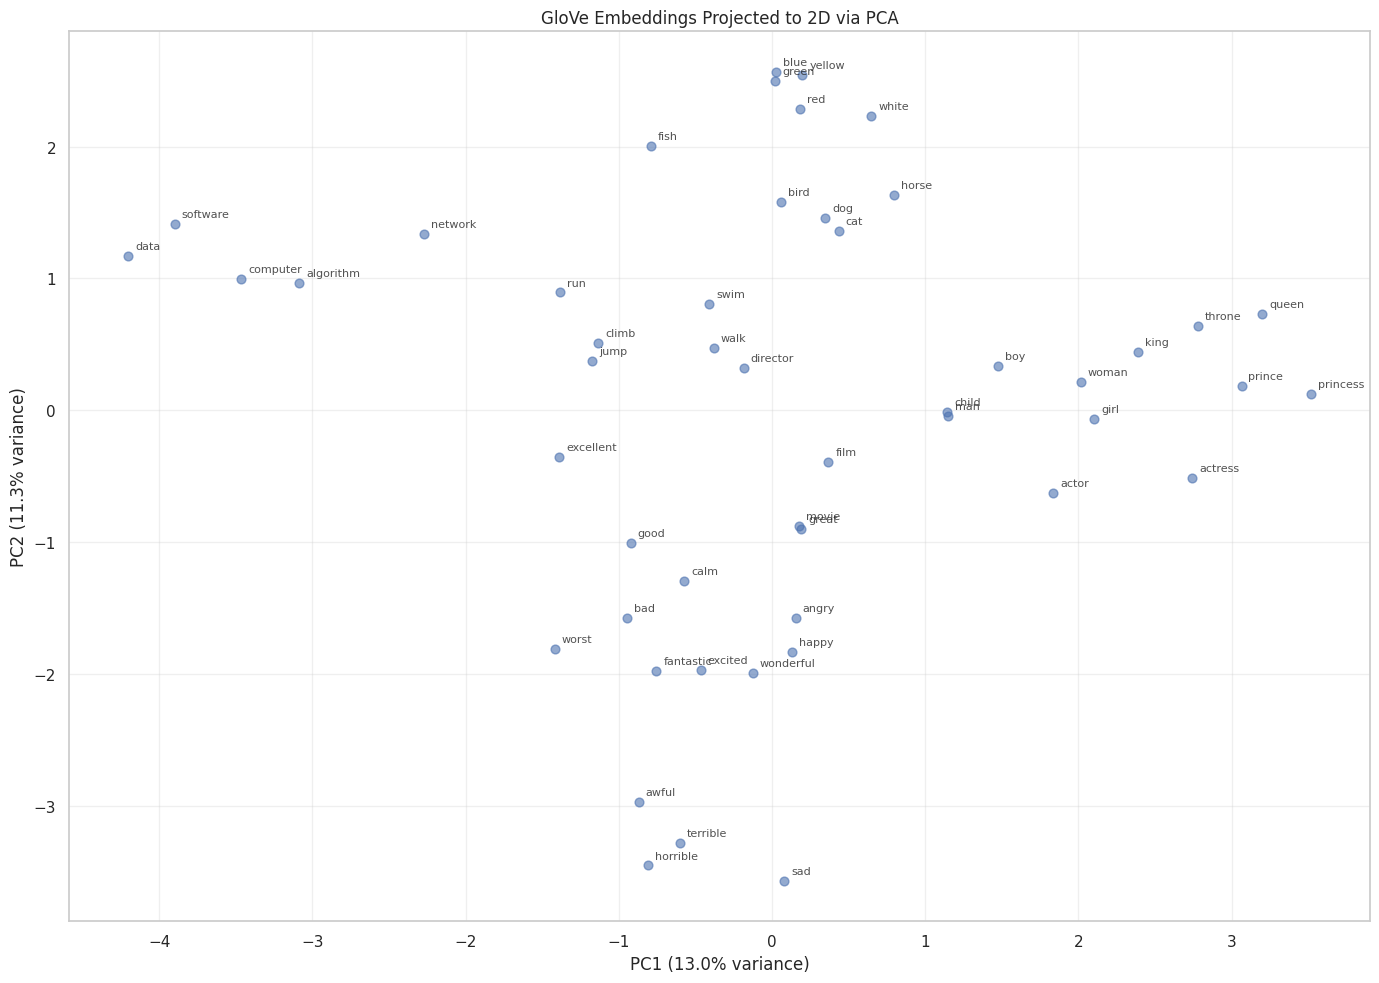

In [44]:
viz_words = [
    "good", "great", "excellent", "wonderful", "fantastic",
    "bad", "terrible", "awful", "horrible", "worst",
    "happy", "sad", "angry", "excited", "calm",
    "movie", "film", "actor", "actress", "director",
    "king", "queen", "prince", "princess", "throne",
    "dog", "cat", "horse", "fish", "bird",
    "computer", "software", "algorithm", "data", "network",
    "man", "woman", "boy", "girl", "child",
    "run", "walk", "swim", "jump", "climb",
    "red", "blue", "green", "yellow", "white",
]

# Collect embedding vectors for words that exist in GloVe vocabulary
viz_vectors = []
viz_labels = []
for word in viz_words:
    if word in glove.stoi:
        viz_vectors.append(glove[word].numpy())
        viz_labels.append(word)

# Convert list of vectors to numpy array for PCA
viz_matrix = np.array(viz_vectors)
print(f"Visualizing {len(viz_labels)} words in 2D")

# Apply PCA to reduce 100-dimensional embeddings to 2D for visualization
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(viz_matrix)

# Create scatter plot of word embeddings in 2D space
plt.figure(figsize=(14, 10))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.6, s=40)

# Annotate each point with its corresponding word
for i, label in enumerate(viz_labels):
    plt.annotate(label, (coords_2d[i, 0], coords_2d[i, 1]),
                 fontsize=8, alpha=0.8,
                 xytext=(5, 5), textcoords='offset points')

# Add labels and formatting
plt.title("GloVe Embeddings Projected to 2D via PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** You should see clusters forming -- positive sentiment words near each other, negative sentiment words near each other, animals grouping together, royalty grouping together, etc. This is the distributional hypothesis in action: words that appear in similar contexts have similar vectors.

In [45]:
show_todo("Work through Section 4: Bag-of-Embeddings Classifier")

## Section 4: Bag-of-Embeddings Classifier

We still don't have a text classifier model to work with yet. Let's add our first text model. It's called a `Bag-of-Embeddings` classifier. The way it works is simple: each word in a document is converted to its embedding vector, then all word vectors are averaged together (ignoring padding tokens) to produce a single document-level representation. This averaged vector is then passed through a standard feedforward classifier head to produce class predictions. Despite its simplicity, this architecture provides a strong baseline for text classification tasks.

Our aims for this section:
- Implement a text classifier using a learned embedding layer and mean pooling
- Understand why padding tokens must be masked out during pooling
- Load pretrained GloVe weights into a PyTorch `nn.Embedding` layer
- Empirically compare random vs. pretrained embedding initialization

### Architecture Overview

The Bag-of-Embeddings (BoE) classifier is the NLP analog of Global Average Pooling (GAP)
from CNN architectures:

| CNN (hw07) | Bag-of-Embeddings (this section) |
|---|---|
| Feature maps: `(batch, C, H, W)` | Token embeddings: `(batch, L, D)` |
| GAP averages over spatial dims `(H, W)` | Mean Pool averages over sequence dim `L` |
| Output: channel summary `(batch, C)` | Output: document summary `(batch, D)` |

The full forward pipeline is:
```
Token IDs  →  Embedding  →  Masked Mean Pool  →  Classifier Head  →  Logits
(batch, L)    (batch,L,D)      (batch, D)          (batch, D→H→C)    (batch, C)
```
where **L** = sequence length, **D** = embedding dimension, **C** = number of classes,
**H** = hidden layer size(s).

**Why masked mean pooling?**
Sequences in a batch are padded to the same length. Padding tokens (index 0) carry a
zero vector and should not dilute the document representation. By creating a binary mask
that is 1 for real tokens and 0 for padding, we sum only over real tokens and divide by
the count of real tokens — producing the true average embedding of the document's words.

### Step 4.1 - Refactoring the classifier head functionality

When we created `CNN_Model`, we learned that many neural net models differ in the architecture of the earlier layers, but often end with the standard fully connected layer at the end (though CNN_Model). It turns out that pattern will persist through a lot of our work. Let's apply an **extract method** refactoring on the construction of the fully connected layer. 

First, we will create a helper method in `model.py` that extracts a common pattern we're applying in many of our models - creation of fully-connected multiple layers. It'll take three parameters:
* `start_layer_size` - the layer size to start the first layer with
* `config` - The `ModelConfig` instance that will provide the `hidden_units` and `dropout` configuration
* `num_outputs` - the number of outputs for the final layer

We'll give you this entire helper method:
```python
def _construct_fc_layers(start_layer_size: int, config: ModelConfig, num_outputs: int) -> nn.Sequential:
    """Build a fully-connected classifier head.

    Constructs a stack of Linear -> ReLU -> Dropout layers from config.hidden_units
    and config.dropout, followed by a final Linear(last_hidden, num_outputs) layer.

    Args:
        start_layer_size: Input feature dimension to the first linear layer.
        config: ModelConfig supplying hidden_units and dropout lists.
        num_outputs: Number of output logits for the final linear layer.

    Returns:
        nn.Sequential containing the complete classifier head.
    """
    layers = []
    prev_size = start_layer_size
    for i, hidden_size in enumerate(config.hidden_units):
        layers.append(nn.Linear(prev_size, hidden_size))
        layers.append(nn.ReLU())
        if i < len(config.dropout):
            layers.append(nn.Dropout(config.dropout[i]))
        prev_size = hidden_size
    layers.append(nn.Linear(prev_size, num_outputs))
    return nn.Sequential(*layers)

```

Then, update your `CNN_Model` constructor to use this method. Replace the construction of the classifier head with this single line in your constructor:

```python
        ...
        # --- Build the classifier head ---
        self.classifier_head = _construct_fc_layers(
            start_layer_size=self._flat_features, 
            config=config, 
            num_outputs=num_outputs)
```

### Step 4.2: Implement `BagOfEmbeddings` in `model.py`

Open `src/my_engine/model.py` and add the class below. The TODOs inside the class
guide you through each component. Read the docstring and inline comments carefully
before writing any code — each design decision is explained.

Key PyTorch APIs you will use:
- `nn.Embedding(num_embeddings, embedding_dim, padding_idx)` — look-up table mapping
  token IDs to dense vectors. `padding_idx` rows are held at zero and never updated.
- `tensor.requires_grad = False` — detaches a parameter from the computation graph,
  preventing gradient updates (used to freeze pretrained embeddings).
- `tensor.unsqueeze(-1)` — adds a trailing dimension for broadcasting.
- `tensor.clamp(min=1)` — prevents division-by-zero for empty sequences.

```python
class BagOfEmbeddings(nn.Module):
    """Bag-of-Embeddings text classifier.

    Architecture:
        Embedding -> Masked Mean Pool -> Classifier Head

    The embedding layer converts token indices to dense vectors. Mean pooling
    averages the token embeddings over the sequence dimension, *excluding* padding
    tokens, producing a fixed-size document vector regardless of sequence length.
    The classifier head is a stack of Linear + ReLU + Dropout layers, reusing
    the same motif as MLP_Model.

    This is the NLP analog of Global Average Pooling (GAP) from CNN architectures:
    GAP averages over spatial dimensions (H, W); mean pooling averages over the
    sequence dimension L.

    Args:
        num_outputs (int): Number of output classes (e.g., 2 for binary sentiment).
        config (ModelConfig): Hyperparameter configuration. Relevant fields:
            vocab_size      -- number of rows in the embedding matrix
            embedding_dim   -- width (D) of each embedding vector
            padding_idx     -- token ID treated as padding (kept at zero vector)
            freeze_embeddings -- if True, embedding weights are not updated
            hidden_units    -- list of hidden layer sizes for the classifier head
            dropout         -- list of dropout rates (one per hidden layer)
    """
    def __init__(self, num_outputs: int, config: ModelConfig):
        super().__init__()
        if config.model_type != "bow":
            raise ValueError(f"Invalid model_type: {config.model_type}. Expected 'bow'.")

        self.num_outputs = num_outputs
        self.config = config

        # --- Embedding layer ---
        # TODO: Create self.embedding using nn.Embedding.
        #       Pass config.vocab_size, config.embedding_dim, and config.padding_idx.
        #       PyTorch will automatically keep the padding_idx row as a zero vector
        #       and will not update it during backprop.
        self.embedding = ???

        # TODO: If config.freeze_embeddings is True, prevent the embedding weights
        #       from receiving gradient updates by setting requires_grad = False.
        #       This is useful when you want to preserve pretrained GloVe knowledge
        #       and only train the classifier head (see Challenge 1).
        if config.freeze_embeddings:
            ???

        # --- Classifier head: embedding_dim -> hidden_units -> num_outputs ---
        self.classifier_head = _construct_fc_layers(
            start_layer_size=config.embedding_dim, 
            config=config, 
            num_outputs=num_outputs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: LongTensor of token IDs, shape (batch_size, seq_len).

        Returns:
            Logit tensor of shape (batch_size, num_outputs).
        """
        # TODO: Step 1 — Look up embeddings for each token ID.
        #       self.embedding(x) maps each integer ID to its D-dimensional vector.
        #       Result shape: (batch_size, seq_len, embedding_dim)
        ???

        # TODO: Step 2 — Build the padding mask.
        #       Create a float tensor that is 1.0 where x != padding_idx, 0.0 elsewhere.
        #       Unsqueeze the last dimension so it broadcasts over embed_dim.
        #       Shape after unsqueeze: (batch_size, seq_len, 1)
        mask = ???

        # Step 3 — Masked mean pooling.
        #       Multiply embeddings by the mask to zero out padding positions,
        #       sum over the sequence dimension (dim=1), then divide by the count
        #       of real tokens. Clamp the denominator to at least 1 to avoid
        #       division-by-zero on hypothetical all-padding sequences.
        summed = (embedded * mask).sum(dim=1)          # (batch, embed_dim)
        lengths = mask.sum(dim=1).clamp(min=1)         # (batch, 1)
        pooled  = summed / lengths                     # (batch, embed_dim)

        # TODO: Step 4 — Pass the document vector through the classifier head.
        return ???

    def num_parameters(self) -> tuple[int, int]:
        """Returns (total_params, trainable_params)."""
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

    def get_architecture_config(self) -> dict:
        """Returns a serializable dictionary describing the full model architecture."""
        from dataclasses import asdict
        return {
            "model_class": "BagOfEmbeddings",
            "num_outputs": self.num_outputs,
            "config": asdict(self.config),
        }

    def __str__(self) -> str:
        frozen = "frozen" if self.config.freeze_embeddings else "trainable"
        return (
            f"BagOfEmbeddings(vocab={self.config.vocab_size}, "
            f"embed_dim={self.config.embedding_dim}, {frozen})\n"
            f"  head=[{self.config.embedding_dim} -> "
            f"{self.config.hidden_units} -> {self.num_outputs}]\n"
            f"  dropout={self.config.dropout}"
        )

    def __repr__(self) -> str:
        return self.__str__()

```

### Step 4.3: Register `"bow"` in `build_model` (`utils.py`)

Open `src/my_engine/utils.py`. Add `BagOfEmbeddings` to the import and a new branch
for `model_type == "bow"` inside `build_model`. The `input_spec` parameter is not used
for BoE models (the vocab size comes from `config.vocab_size`), but keep the function
signature consistent with the other branches.

```python
# Add BagOfEmbeddings to the existing model import at the top of utils.py:
from src.my_engine.model import MLP_Model, CNN_Model, BagOfEmbeddings

def build_model(input_spec, num_outputs, config: ModelConfig):
    ...
    elif config.model_type == "bow":
        # TODO: Instantiate and return a BagOfEmbeddings model.
        #       input_spec is unused here; vocab_size lives in config.
        model = ???
    ...
```
> `"bow"` is a common NLP abbreviation that stands for "Bag of Words". It's a very common model in NLP that discards all order when modeling text, and is consistent with what we're doing with the `BagOfEmbeddings` class 

### Step 4.4: Verify `BagOfEmbeddings` — Shape Check

Before launching a full training run, always verify that your model produces the
correct output shape on a small dummy batch. Catching shape errors now saves time.

The expected forward-pass shapes for a batch of 8 sequences of length 50:
```
Input  x:           (8, 50)              — token ID integers
After embedding:    (8, 50, 100)          — one 100-d vector per token
After mean pool:    (8, 100)              — one document vector per sample
After classifier:   (8, 2)               — one logit per class per sample
```

Your code to output the number of parameters should result in the following:
```
Total parameters:     2,506,794
Trainable parameters: 2,506,794
Embedding layer:      2,500,200  (99.7% of total)
```

In [46]:
from lantern.config import ModelConfig, ModelType
from lantern.model import BagOfEmbeddings
from lantern.utils import build_model

# Create a ModelConfig for a "bow" model.
#       Use the IMDB vocabulary size, embedding_dim=100, padding_idx=0,
#       hidden_units=[64], dropout=[0.3].
bow_config = ModelConfig(
    model_type=ModelType.BOW,
    embedding_dim=100,
    vocab_size=len(imdb_vocab),
    padding_idx=0,
    hidden_units=[64],
    dropout=[0.3],
)   

# Instantiate BagOfEmbeddings with 2 output classes and bow_config.
bow_model = build_model(input_spec=0, num_outputs=2, config=bow_config)
print(bow_model)

total, trainable = bow_model.num_parameters()
print(f"\nTotal parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Embedding layer:      {bow_config.vocab_size * bow_config.embedding_dim:,}  "
      f"({100 * bow_config.vocab_size * bow_config.embedding_dim / total:.1f}% of total)")

BagOfEmbeddings(vocab=25002, embed_dim=100, trainable)
  head=[100 -> [64] -> 2]
  dropout=[0.3]

Total parameters:     2,506,794
Trainable parameters: 2,506,794
Embedding layer:      2,500,200  (99.7% of total)


In [ ]:
# Create a random dummy batch: 8 sequences, each of length 50.
#  Use torch.randint with low=0, high=len(imdb_vocab) and size=(8, 50).
#  Run it through bow_model and assert the output is shape (8, 2).
dummy_batch  = torch.randint(low=0, high=len(imdb_vocab), size=(8, 50))   # (batch=8, seq_len=50)
dummy_output = bow_model(dummy_batch)

print(f"Input shape:  {dummy_batch.shape}")    # Expected: torch.Size([8, 50])
print(f"Output shape: {dummy_output.shape}")   # Expected: torch.Size([8, 2])

assert dummy_output.shape == (8, 2), (
    f"Shape mismatch — expected (8, 2), got {dummy_output.shape}. "
    "Check your forward() implementation in model.py."
)
print("Shape check passed!")

Input shape:  torch.Size([8, 50])
Output shape: torch.Size([8, 2])
Shape check passed!


In [48]:
show_warning("Do not proceed until the shape check above passes. "
             "If BagOfEmbeddings is not importable, re-check your additions "
             "to model.py (class definition) and utils.py (build_model branch).")

In [49]:
from lantern.config import TrainerConfig, MetricsConfig
from lantern.utils import make_optimizer
from lantern.trainer import Trainer

### CHECKPOINT 1

### Reflective Exercise 4-A: Architecture Design

Answer the questions below *before* moving on to training. These are conceptual
checks on the design choices you just implemented.

**R1:** The padding mask ensures that `<PAD>` tokens (used to fill out sequences to a common length) are ignored when computing the mean embedding for a sequence. What would happen if you simply called `embedded.mean(dim=1)` and included all tokens (including the padding tokens) in the average? Suppose the longest review was 200 tokens, and you were passing a review of only 20 tokens. 

**ANSWER:**
<br>
Then the average of the embeddings would be skewed towards `<PAD>`, which has no meaning. 
<br>

**R2:** How many parameters does the embedding layer contribute versus the classifier head? 
Calculate both counts manually using a vocabulary size of 25,000. Then express the embedding layer's share as a percentage.
(Hint: embedding = `vocab_size × embedding_dim`; head = `(D×H + H) + (H×C + C)`.)

**ANSWER:**
<br>
embedding = 25,000 * 100 = 2,500,000
head = (100 * 64 + 64) + (64*2 + 2) = 6,594

embedding percent = 2,500,000 / 2,506,594 = 99.7%
<br>

### Step 4.5: Train with Random Embeddings (Run A)

We will train two configurations and compare them side-by-side:

| Run | Embedding Init | `freeze_embeddings` | What is learned? |
|-----|---------------|---------------------|-----------------|
| A   | Random (N(0,1)) | False             | Embeddings + head, both from scratch |
| B   | Pretrained GloVe| False             | Embeddings fine-tuned from GloVe init |

Run A is the baseline. The embedding weights start random and must learn word semantics
entirely from the binary sentiment signal during training.

In [51]:
from lantern.config import TrainerConfig, MetricsConfig
from lantern.utils import make_optimizer
from lantern.trainer import Trainer

In [52]:
# Select the number of training epochs based on the global run-mode flag.
# FULL = production run (10 epochs), QUICK = smoke test (3 epochs), SKIP = no training.
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 4
else:
    num_epochs = 0

# Configure the Trainer with the hyperparameters listed below.
#       These settings will be shared by both Run A and Run B.
#       - trainer_batch_size=64, evaluator_batch_size=256
#       - learning_rate=1e-3, optimizer_name="adam", weight_decay=1e-5
#       - device=accel_device, num_epochs from above, no early stopping
trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam", 
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
    early_stopping_patience=None
)

# Use the get_dataloaders function to create the dataloaders with the correct batch sizes
imdb_train_loader, imdb_test_loader = get_dataloaders(
    train_dataset=imdb_train_ds,
    test_dataset=imdb_test_ds,
    train_batch_size=64,
    eval_batch_size=256,
    collate_fn=text_collate_fn,
)

#### Run A: Random Embeddings (Trainable)

In [53]:
# Create a ModelConfig for Run A.
#       All embedding fields: vocab_size from imdb_vocab, embedding_dim=100,
#       padding_idx=0, freeze_embeddings=False (embeddings learned from scratch).
#       Classifier head: hidden_units=[64], dropout=[0.3].
config_random = ModelConfig(
    model_type=ModelType.BOW,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    padding_idx=0, 
    freeze_embeddings=False,
    hidden_units=[64], 
    dropout=[0.3],
)

# Create your BagOfEmbeddings model with 2 output classes and config_random.
model_random = build_model(input_spec=0, num_outputs=2, config=config_random)

# Print the number of parameters
total, trainable = model_random.num_parameters()
print(f"Run A — Random Embeddings:  total={total:,}  trainable={trainable:,}")

run_a = None
run_a = wandb.init(
    project="csci357-hw08-bow",
    # entity=entity,
    name=f"{user_initials}-random-emb",
    reinit=True,
    settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
)

# Instantiate a Trainer and call trainer.fit(imdb_train_loader, imdb_test_loader).
#       Use nn.CrossEntropyLoss() as the criterion and MetricsConfig(task="binary",
#       names=["accuracy"]) to track accuracy during training.
optimizer = make_optimizer(model_random.parameters(),trainer_config)
with Trainer(
    model=model_random,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy"]),
    run=run_a
) as trainer:
    results_a = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"\nRun A Final Results: {results_a}")

Run A — Random Embeddings:  total=2,506,794  trainable=2,506,794
Epoch 0:
Train Accuracy=69.89%  Val Accuracy=82.02%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=85.79%  Val Accuracy=86.16%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=89.68%  Val Accuracy=87.18%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=92.03%  Val Accuracy=87.87%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt

Run A Final Results: {'num_epochs': 4, 'train_accuracy': 0.9202799797058105, 'val_accuracy': 0.8786799907684326}


### Step 4.6: Initialize with Pretrained GloVe Embeddings (Run B)

Now we load the GloVe-100d embedding matrix built in Section 3 into the model's
embedding layer. This is called **warm-starting** or **embedding initialization**.

The key API is:
```python
model.embedding.weight.data.copy_(pretrained_matrix)
```
`.data` accesses the underlying tensor without tracking the assignment as a gradient
operation. `.copy_()` copies in-place, preserving the tensor's device and dtype.

After this call, training proceeds normally — gradients will flow through the embedding
layer and fine-tune the GloVe vectors on the IMDB task (`freeze_embeddings=False`).

#### Run B: Pretrained GloVe Embeddings (Fine-Tuned)

In [54]:
# Create a ModelConfig for Run B — identical to Run A.
#       The only difference is in how we will initialize the weights (next step).
config_glove = ModelConfig(
    model_type=ModelType.BOW,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    padding_idx=0, 
    freeze_embeddings=False,
    hidden_units=[64], 
    dropout=[0.3],
)

model_glove = build_model(input_spec=0, num_outputs=2, config=config_glove)

# Load the pretrained GloVe matrix into the embedding layer.
#       glove_matrix has shape (vocab_size, embedding_dim) and was built in Step 3.6.
#       Use .data.copy_() to write the weights in-place without creating a gradient op.
model_glove.embedding.weight.data.copy_(glove_matrix)

total, trainable = model_glove.num_parameters()
print(f"Run B — GloVe Embeddings (fine-tuned):  total={total:,}  trainable={trainable:,}")
print(f"Loaded GloVe matrix: {glove_matrix.shape}")

run_b = None
if DO_WANDB_LOGGING:
    run_b = wandb.init(
        project="csci357-hw08-bow",
        # entity=entity,
        name=f"{user_initials}-glove-finetune",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )

# Train model_glove with the same Trainer configuration used in Run A.
with Trainer(
    model=model_random,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy"]),
    run=run_b
) as trainer:
    results_b = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"\nRun B Final Results: {results_b}")

Run B — GloVe Embeddings (fine-tuned):  total=2,506,794  trainable=2,506,794
Loaded GloVe matrix: torch.Size([25002, 100])
Epoch 0:
Train Accuracy=93.67%  Val Accuracy=87.78%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=95.16%  Val Accuracy=87.74%
Epoch 2:
Train Accuracy=96.22%  Val Accuracy=86.96%
Epoch 3:
Train Accuracy=97.12%  Val Accuracy=86.93%

Run B Final Results: {'num_epochs': 4, 'train_accuracy': 0.9712400436401367, 'val_accuracy': 0.8692799806594849}


### Analysis: Random vs. Pretrained Initialization

In [ ]:
show_todo("Answer the Section 4 analysis questions below")

**DONE:** Answer these questions based on your Run A and Run B results.
Be specific — reference actual accuracy and loss values from your runs.

**Q1:** How does pretrained GloVe initialization compare to random initialization?
Compare first-epoch accuracy, final accuracy, and the shape of the loss curves.
Does GloVe start with a measurably higher first-epoch accuracy? Does the gap persist
to the end of training, or do both runs converge to similar final performance?

**ANSWER:**
<br>
The first-epoch accuracy of the pretraied GloVe initialization is better, but the final accuracy is worse. The train accuracy seems to be converging but the val accuracy does not, but this could be because only a QUICK number of epochs was used (forgot to change it).
<br>

**Q2:** This model uses mean pooling over word embeddings (Bag-of-Embeddings). What
information does it capture? What is it fundamentally unable to capture? Provide a
concrete sentence pair that would produce nearly identical pooled vectors yet carry
opposite sentiments.

**ANSWER:**
<br>
Mean pooling captures the general semantic content of the text (which words are present and roughly what they mean). It cannot capture the word order, syntax, and negation present in the text. It is just an average of all the tokens in the text.

Example of concrete sentence pair with opposite sentiments but nearly identical pooled vectors:
- "The acting was good, not terrible."
- "The acting was terrible, not good."
<br>

### Reflective Exercise 4-B: Transfer Learning Connections

**R1:** In hw07, you used a pretrained ResNet backbone for image classification.
Loading GloVe into the embedding layer follows an analogous pattern. Identify the
exact parallel: what plays the role of the *pretrained backbone*, the *task-specific
head*, and the *fine-tuning* step in the two workflows?

**ANSWER:**
<br>
In both cases we're initializing a representation layer with weights learned on a large external dataset (ImageNet / the GloVe co-occurrence corpus), then training only a small head on top for your specific task. Freezing vs unfreezing controls whether the pretrained knowledge is preserved exactly or allowed to adapt.
<br>

**R2:** Bag-of-Embeddings and Bag-of-Words (from Section 2) both discard word order.
What representational advantage does BoE provide over BoW, even though neither model
can capture syntax or negation?

**ANSWER:**
<br>
BoW represents each document as a sparse vector of vocabulary size (~50k+), where each dimension is a word count. Words with similar meanings ("good", "great", "excellent") get completely separate dimensions with no relationship between them.

BoE maps each word to a dense low-dimensional vector (e.g. 100d) where semantic similarity is encoded geometrically; "good" and "great" have nearby vectors because GloVe learned from co-occurrence patterns. After mean pooling, two documents with synonymous but non-identical vocabulary can still produce similar document vectors.
<br>

### Step 4.7 - Add sweep support

1. Open `sweep.py`. In your `train_sweep()` method that is returned by `make_train_sweep()`, add the support for your new parameters:

```python
        use_GAP = getattr(config, "use_GAP", default_model_config.use_GAP)

        # NLP / embedding 
        vocab_size = getattr(config, "vocab_size", default_model_config.vocab_size)
        embedding_dim = getattr(config, "embedding_dim", default_model_config.embedding_dim)
        padding_idx = getattr(config, "padding_idx", default_model_config.padding_idx)
        freeze_embeddings = getattr(config, "freeze_embeddings", default_model_config.freeze_embeddings)

```

2. Provide a better `run.name`

```python
        if model_type == "bow":
            run.name = f"{model_type}_bs{trainer_batch_size}_lr{learning_rate:.5f}_vs{vocab_size}_ed{embedding_dim}_wd{weight_decay:.5f}"
        else:
            hidden_str = "x".join(map(str, hidden_units))
            run.name = f"{model_type}_bs{trainer_batch_size}_lr{learning_rate:.5f}_h{hidden_str}_wd{weight_decay:.5f}_m{momentum:.2f}"
        if wandb_name_prefix is not None:
            run.name = f"{wandb_name_prefix}_{run.name}"
        print(f"Run name set to: {run.name}")

```

Add support to use a collate_fn parameter with the `get_dataloaders`. (NOTE: You may not even have get_dataloaders, and perhaps you are instead just instantiating two dataloaders. Fix your code to use `get_dataloaders`.)

```python
        # Set up dataloaders
        collate_fn = None
        if model_type == "bow":
            collate_fn = text_collate_fn

        # Create DataLoaders using the captured train_dataset and val_dataset
        train_loader, val_loader = get_dataloaders(
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            train_batch_size=trainer_batch_size,
            eval_batch_size=evaluator_batch_size,
            collate_fn=collate_fn,
            num_workers=num_workers,
            pin_memory=pin_memory,
        )

```

Finally, add support to set these parameters correctly when instantiating `ModelConfig`:

```python
        model_config = ModelConfig(
            model_type=model_type,
            hidden_units=hidden_units,
            dropout=dropout,
            conv_blocks=conv_blocks,
            in_channels=in_channels,
            use_GAP=use_GAP,

            # NLP / embedding parameters
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx,
            freeze_embeddings=freeze_embeddings,

```

That's it! You should be all set for full sweep configuration. Just keep in mind that you'll need to add the correct sweep parameters for the BagOfEmbeddings model For example:

```python
        # --- BOW / embedding ---
        "embedding_dim": {"values": [100, 200]},
```

The `vocab_size` wouldn't change for a given dataset, and you usually just leave the `padding_idx` alone. And, `freeze_embeddings` would only be tested on problems where you are using pretrained embeddings.

In [ ]:
show_todo("Work through Section 5: Analyzing the Embedding Space")

## Section 5: Analyzing the Embedding Space

Now that we have a trained model, let's look inside the embedding layer to see what it learned.

### Step 5.1: Visualize Learned Embeddings After Training

Extract the trained embedding weights and visualize them alongside the original GloVe embeddings. We will use the same set of words from Section 3.

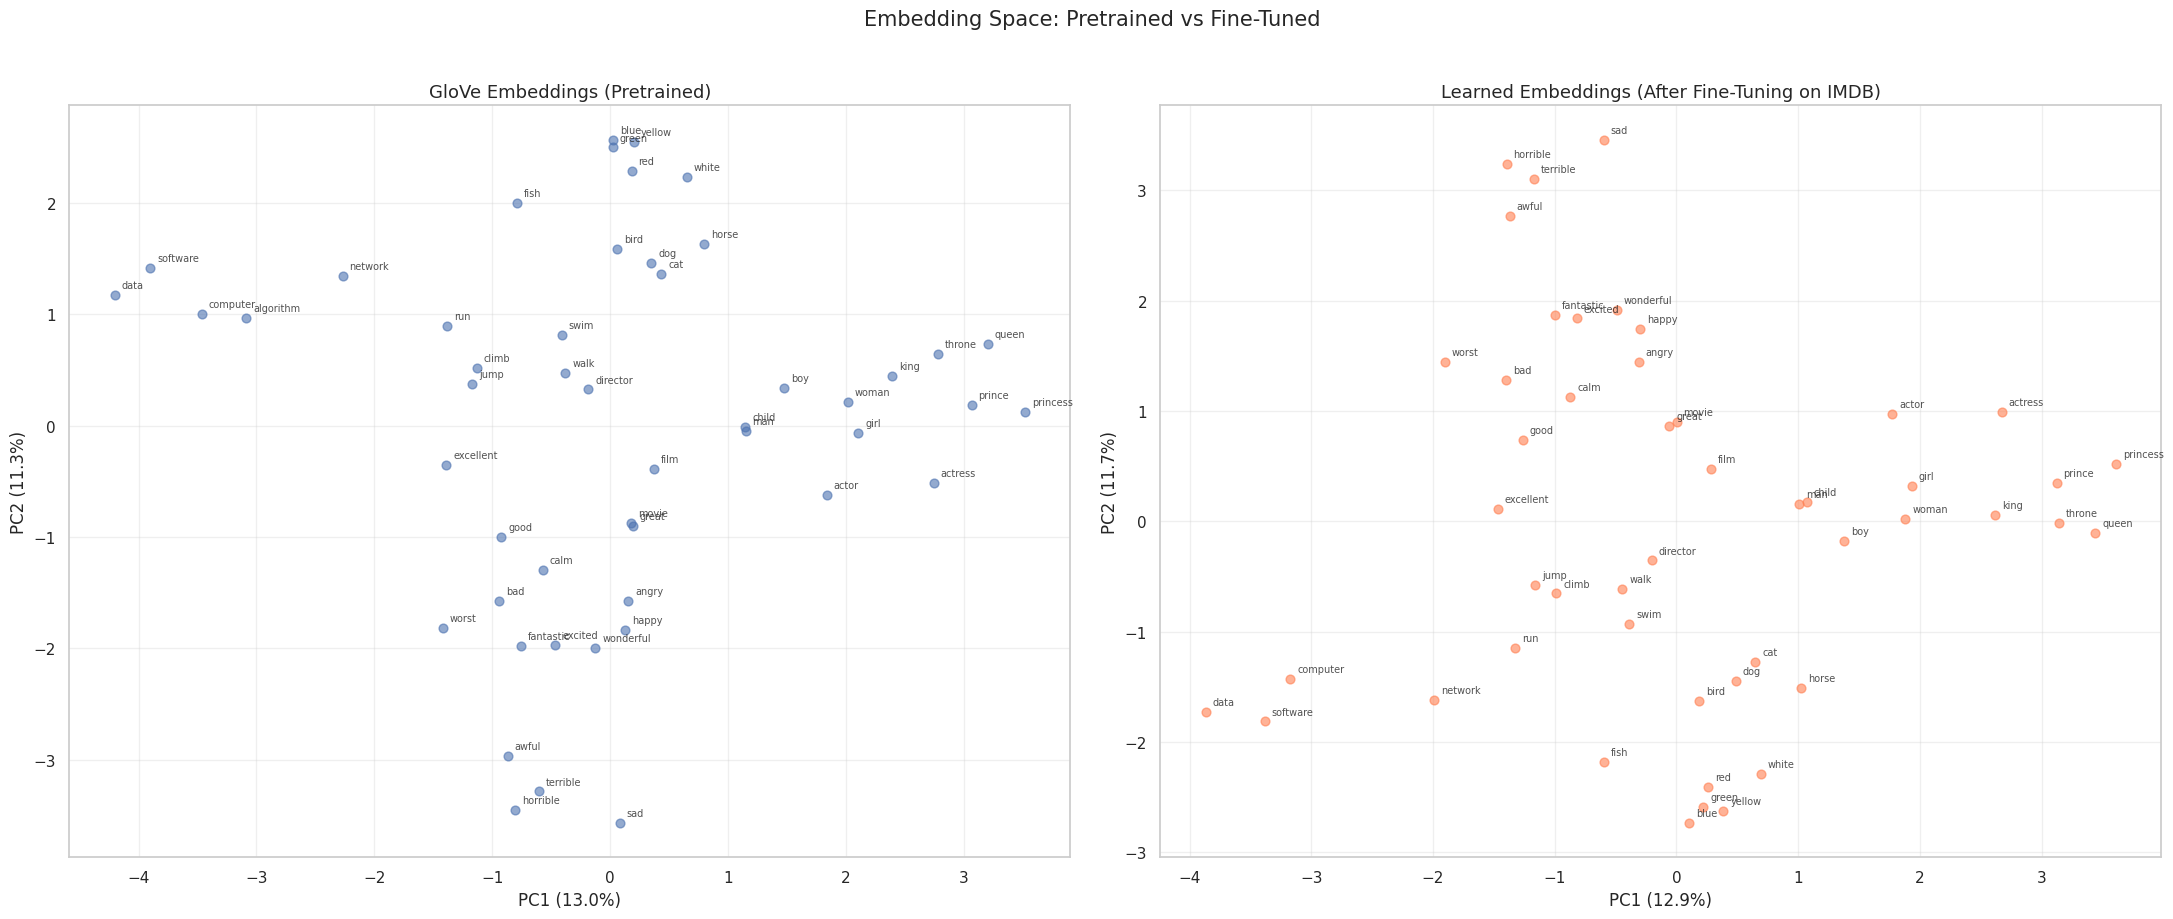

In [56]:
trained_weights = model_glove.embedding.weight.data.cpu()

trained_vectors = []
trained_labels = []
for word in viz_words:
    if word in imdb_vocab:
        idx = imdb_vocab[word]
        trained_vectors.append(trained_weights[idx].numpy())
        trained_labels.append(word)

trained_matrix = np.array(trained_vectors)

pca_trained = PCA(n_components=2)
coords_trained = pca_trained.fit_transform(trained_matrix)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Original GloVe
axes[0].scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.6, s=40)
for i, label in enumerate(viz_labels):
    axes[0].annotate(label, (coords_2d[i, 0], coords_2d[i, 1]),
                     fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')
axes[0].set_title("GloVe Embeddings (Pretrained)", fontsize=13)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].grid(True, alpha=0.3)

# After fine-tuning
axes[1].scatter(coords_trained[:, 0], coords_trained[:, 1], alpha=0.6, s=40, color='coral')
for i, label in enumerate(trained_labels):
    axes[1].annotate(label, (coords_trained[i, 0], coords_trained[i, 1]),
                     fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')
axes[1].set_title("Learned Embeddings (After Fine-Tuning on IMDB)", fontsize=13)
axes[1].set_xlabel(f"PC1 ({pca_trained.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_trained.explained_variance_ratio_[1]:.1%})")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Embedding Space: Pretrained vs Fine-Tuned", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Step 5.2: Cosine Similarity Between Word Pairs

Let's compare cosine similarities in the original GloVe space vs. the fine-tuned space. Do the fine-tuned embeddings better capture sentiment relationships?

In [57]:
word_pairs = [
    ("great", "wonderful"),
    ("awful", "horrible"),
    ("happy", "sad"),
    ("worst", "excellent"),
    ("movie", "film"),
    ("king", "queen"),
    ("dog", "cat"),
]

print(f"{'Word Pair':<25s} {'GloVe':>8s}  {'Fine-Tuned':>10s}  {'Delta':>8s}")
print("-" * 60)

for w1, w2 in word_pairs:
    if w1 in glove.stoi and w2 in glove.stoi and w1 in imdb_vocab and w2 in imdb_vocab:
        glove_sim = F.cosine_similarity(
            glove[w1].unsqueeze(0), glove[w2].unsqueeze(0)
        ).item()
        ft_sim = F.cosine_similarity(
            trained_weights[imdb_vocab[w1]].unsqueeze(0),
            trained_weights[imdb_vocab[w2]].unsqueeze(0),
        ).item()
        delta = ft_sim - glove_sim
        print(f"({w1}, {w2}){'':<{20 - len(w1) - len(w2)}} {glove_sim:>8.4f}  {ft_sim:>10.4f}  {delta:>+8.4f}")

Word Pair                    GloVe  Fine-Tuned     Delta
------------------------------------------------------------
(great, wonderful)         0.6993      0.6993   +0.0000
(awful, horrible)          0.9220      0.9220   +0.0000
(happy, sad)               0.6801      0.6801   +0.0000
(worst, excellent)         0.3368      0.3368   +0.0000
(movie, film)              0.9055      0.9055   +0.0000
(king, queen)              0.7508      0.7508   +0.0000
(dog, cat)                 0.8798      0.8798   +0.0000


**Observation:** Recall that Cosine Similarity ranges between 1 (identical) to -1 (completely different). After fine-tuning on a sentiment task, you should notice that sentiment-aligned word pairs (good/great, terrible/awful) become *more* similar, while sentiment-opposed pairs (good/bad, terrible/wonderful) become *less* similar. The model is reshaping the embedding space to be more useful for its specific task. Pairs that are irrelevant to sentiment (king/queen, dog/cat) may change less.

### Step 5.3: Limitations of Static Embeddings

**Discussion:** The embeddings we explored -- both GloVe and our fine-tuned version -- are **static**: every word has exactly one vector, regardless of context. Consider the word "bank":

* *"I deposited money at the bank"* (financial institution)
* *"We sat on the river bank"* (edge of a river)

The term "bank" would map to the same embedding vector in both cases. The model has no way to distinguish these meanings. This is the **polysemy problem** -- a fundamental limitation of static word embeddings.

Similarly, "not good" and "good" share the same vector for "good". The negation "not" modifies the meaning, but static embeddings treat each word independently.

Modern approaches solve this with **contextualized embeddings** (ELMo, BERT, GPT) where the same word gets different vectors depending on its surrounding context. We will encounter this idea later in the semester when we study Transformers, and you'll get a taste in Challenge 5 of how we can take context into consideration in a model. For now, understand that static embeddings are a powerful but limited first step.

In [ ]:
show_todo("Answer the embedding analysis questions below")

**DONE:** Answer these questions based on your visualizations and similarity analysis.

**Q1:** Compare the PCA plots of GloVe embeddings vs. fine-tuned embeddings. How did the embedding space change after training on IMDB? Did sentiment-related words move closer together or further apart?

**ANSWER:**
<br>
Sentiment-related words moved closer together. We can also see some groups of words like those related to software moved down on PC2.
<br>

**Q2:** Why might fine-tuned embeddings perform better for sentiment analysis but worse for word analogy tasks like king - man + woman = queen?

**ANSWER:**
<br>
Fine-tuned embeddings perform better for sentiment analysis because they are specifically trained to optimize separating positive from negative sentiment. Words will get repositioned to minimize sentiment classification loss. That's why words that do not have any relation to sentiment like king, man, woman, and queen may start to drift apart with gradient updates that optimize for sentiment classification.
<br>

In [ ]:
show_section()

---
# Challenges

This week's challenges extend the Bag-of-Embeddings baseline in two directions: (1) exploring the impact of freezing vs. fine-tuning pretrained embeddings, (2) applying your CNN knowledge from hw07 to text via 1D convolutions on a new dataset (AG News), and (3) a sweep competition.

## Challenge 1: Frozen vs. Fine-Tuned Embeddings

In Section 4, we used GloVe embeddings that were fine-tuned (gradients flowed through the embedding layer). But sometimes freezing the embeddings is preferable -- especially when your training set is small and you want to prevent the pretrained knowledge from being overwritten.

**Your task:**
1. Train a Bag-of-Embeddings model on IMDB with **frozen** GloVe embeddings (`freeze_embeddings=True`in the `ModelConfig`). 
2. Try a couple of hidden_unit configurations to determine if more complex classifier heads give better results.
3. Compare against your fine-tuned GloVe model from the Lab (Run B).
4. Answer the analysis questions below.

**Hint:** When embeddings are frozen, the only trainable parameters are in the classifier head. This dramatically reduces the trainable parameter count.

In [50]:
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 15
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 4
else:
    num_epochs = 0


trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam", 
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
    early_stopping_patience=None
)

# Train with frozen GloVe embeddings
config_frozen = ModelConfig(
    model_type=ModelType.BOW,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    padding_idx=0, 
    freeze_embeddings=True,
    hidden_units=[128, 64], 
    dropout=[0.3],
)

# Create your BagOfEmbeddings model with 2 output classes and config_frozen.
model_frozen = build_model(input_spec=0, num_outputs=2, config=config_frozen)

# Load the pretrained GloVe matrix into the embedding layer.
model_frozen.embedding.weight.data.copy_(glove_matrix)

print(f"Frozen GloVe model: {model_frozen.num_parameters()}")

imdb_train_loader, imdb_test_loader = get_dataloaders(
    train_dataset=imdb_train_ds,
    test_dataset=imdb_test_ds,
    train_batch_size=64,
    eval_batch_size=256,
    collate_fn=text_collate_fn,
)

run_c = None
if DO_WANDB_LOGGING:
    run_c = wandb.init(
        project="csci357-hw08-chal-01",
        entity=entity,
        name=f"{user_initials}-glove-freeze",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )

# Train the frozen model, but be sure to pass only parameters that require gradients
# HINT Use     optimizer=make_optimizer(filter(lambda p: p.requires_grad, model_frozen.parameters()), trainer_config)
optimizer = make_optimizer(filter(lambda p: p.requires_grad, model_frozen.parameters()), trainer_config)
with Trainer(
    model=model_frozen,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy"]),
    run=run_c
) as trainer:
    results_frozen = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"\nFrozen Results: {results_frozen}")

Frozen GloVe model: (2521514, 21314)


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 0:
Train Accuracy=70.59%  Val Accuracy=76.68%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=77.35%  Val Accuracy=72.02%
Epoch 2:
Train Accuracy=77.44%  Val Accuracy=78.34%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=78.16%  Val Accuracy=78.82%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=78.71%  Val Accuracy=75.40%
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=78.30%  Val Accuracy=77.80%
Epoch 6:
Train Accuracy=78.45%  Val Accuracy=79.23%
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 7:
Train Accuracy=78.76%  Val Accuracy=78.14%
Epoch 8:
Train Accuracy=79.00%  Val Accuracy=79.42%
--> New best checkpoint saved: ./checkpoint

In [ ]:
show_todo("Answer the Challenge 1 analysis questions")

**DONE:** Answer these questions comparing frozen vs. fine-tuned GloVe embeddings.

**Q1:** Compare the trainable parameter counts between frozen and fine-tuned models. How many parameters does freezing save? What fraction of the total parameters were in the embedding layer?

**ANSWER:**
<br>
The number of trainable parameters decreased by about 2.5 million. We can see that about 2.5 million parameters were in the embedding layer.
<br>

**Q2:** Does fine-tuning GloVe embeddings help or hurt compared to keeping them frozen? Under what circumstances might you prefer frozen embeddings? HINT: Consider why you might prefer frozen embeddings if you had very small training data vs. something like IMDB.

**ANSWER:**
<br>
Fine-tuning GloVe embeddings help with better accuracy and losses for the specific task given. We would prefer frozen embeddings for general task, not specific ones like sentiment analysis. We would also choose frozen embeddings for small training data as there is not enough quality data to properly fine-tune a model to achieve the task.
<br>

## Challenge 2: 1D CNN Text Classifier on AG News

In hw07, you used 2D convolutions (`nn.Conv2d`) to detect spatial patterns in images. Can convolutions also work on **sequences of text**? Let's find out! For this exercise, we're going to explore the AG News dataset - a 4-class topic classification dataset. 

### What is the AG News dataset?

The AG News dataset is a widely used text classification benchmark constructed from over 2,000 news sources collected in 2005. It contains 120,000 training samples and 7,600 test samples, with each entry consisting of a news headline and short description, paired with one of four topic class labels:
  1) World, 
  2) Sports, 
  3) Business, 
  4) Science/Technology.
The dataset is balanced, making it a standard benchmark for evaluating topic classification models on English news data.

### What are 1D convolutions?

In PyTorch, `nn.Conv1d` slides a filter over an input sequence, much like `nn.Conv2d` slid over images. In our case, we want to slide it over the embedding dimension to detect **local word patterns** (n-grams). This is the bridge between your CNN knowledge and NLP.

### Implementing `TextCNN1D`

We're going to name our model `TextCNN1D`

**Architecture:**<br>
```
Token IDs -> Embedding -> Conv1d (multiple filter sizes) -> Max-over-time Pool -> Linear -> Softmax
```

The key idea: filters of size 3 detect trigram patterns, filters of size 4 detect 4-gram patterns, etc. Max-over-time pooling selects the strongest activation for each filter across the entire sequence.

### Your tasks:

For this challenge, we have laid out a variety of steps to guide you through the challenge. You're going complete the following:

1. Download the AG News dataset (4-class topic classification) from HuggingFace
2. Add `filter_sizes` and `num_filters` fields to `ModelConfig` in `config.py`
3. Implement the `TextCNN1D` model in `model.py` with parallel Conv1d branches
4. Update `build_model()` and make_train_sweep factory function to support `model_type='textcnn'`
5. Train and evaluate TextCNN1D on AG News, comparing against Bag-of-Embeddings baseline




### Step 1. Add support for `"ag_news"` in `data.py`

AG News is a 4-class topic classification dataset (World, Sports, Business, Sci/Tech). Get on HuggingFace Hub site and find it. Use the search term "ag_news". Fortunately, everything is 100% identical to downloading "imdb" except for the search string. So, find your `get_hf_text_dataset` function we created above, and add support to download "ag_news".


### Step 2. Add support in `ModelConfig`:

In `config.py`, add two new fields to `ModelConfig` to support the TextCNN1D architecture:

- `filter_sizes`: A list of integers specifying the kernel widths for parallel Conv1d branches. For example, `[3, 4, 5]` means three separate convolutional layers that capture trigrams, 4-grams, and 5-grams respectively.
- `num_filters`: The number of output channels (filters) for each Conv1d branch. If `num_filters=100` and `filter_sizes=[3,4,5]`, you'll have 100 filters of size 3, 100 of size 4, and 100 of size 5, for a total of 300 feature maps after concatenation.

```python
    # --- TextCNN1D fields ---
    filter_sizes: List[int] = field(default_factory=lambda: [3, 4, 5]) # The sizes of the filters to use in the TextCNN1D model.
    num_filters: int = 100 # The number of filters to use in the TextCNN1D model.
```

### Step 3. **Build a `TextCNN1D` model**. 

Despite this being a challenge, we'll give you some scaffolding for this model class. Place this code in `model.py`. Then, focus on completing each method, paying close attention to the comments and the TODO  labels

```python
class TextCNN1D(nn.Module):
    """1D CNN text classifier with multiple filter sizes.

    Implements the Kim (2014) sentence classification architecture: parallel
    Conv1d branches with different filter widths each perform max-over-time
    pooling, and the resulting feature vectors are concatenated before a
    single linear output layer.

    Architecture:
        Embedding -> [Conv1d(fs) -> ReLU -> MaxPool] for each fs
                  -> Concatenate -> Classifier Head (Linear -> ReLU -> Dropout) x N -> Linear

    Args:
        num_outputs (int): Number of output classes (e.g., 2 for binary sentiment).
        config (ModelConfig): Hyperparameter configuration. Relevant fields:
            vocab_size        -- number of rows in the embedding matrix
            embedding_dim     -- width (D) of each embedding vector
            padding_idx       -- token ID treated as padding (zero vector, not updated)
            freeze_embeddings -- if True, embedding weights are not updated during training
            hidden_units      -- list of hidden layer sizes for the classifier head
            dropout           -- list of dropout rates, one per hidden layer
            TWO PARAMETERS SPECIFIC TO TextCNN1D
            num_filters       -- Number of output channels for each Conv1d branch. 
            filter_sizes      -- (tuple[int, ...]): Kernel widths for each parallel branch.

    Raises:
        ValueError: If ``config.model_type`` is not ``'textcnn'``.

    References:
        Yoon Kim. "Convolutional Neural Networks for Sentence Classification."
        EMNLP 2014. https://arxiv.org/abs/1408.5882
    """
    def __init__(self, num_outputs: int, config: ModelConfig):
        """Initializes the TextCNN1D model, building embedding, conv, and output layers.

        Args:
            num_outputs (int): Number of output classes or regression targets.
            config (ModelConfig): Model configuration; must have ``model_type == 'textcnn'``.

        Raises:
            ValueError: If ``config.model_type`` is not ``'textcnn'``.
        """
        super().__init__()

        if config.model_type != "textcnn":
            raise ValueError(f"Invalid model_type: {config.model_type}. Expected 'textcnn'.")

        # Store hyperparameters so they can be retrieved later (e.g., get_architecture_config).
        self.num_outputs = num_outputs
        self.config = config

        # TODO: Embedding table: maps each integer token ID to a dense vector of size embedding_dim.
        # padding_idx ensures the <PAD> row stays at zero and receives no gradient updates.
        self.embedding = ???

        # TODO: Provide the option to freeze pretrained embeddings (e.g., GloVe)
        if config.freeze_embeddings:
            ???

        # TODO: One Conv1d branch per filter size; each branch independently scans the sequence
        # with a different n-gram width, capturing features at different granularities.
        self.convs = ???

        # TODO: Use your _construct_fc_layers to build the classifier head 
        self.classifier_head = ???

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Runs the forward pass.

        Args:
            x (torch.Tensor): LongTensor of token IDs, shape ``(batch_size, seq_len)``.

        Returns:
            torch.Tensor: Logit tensor of shape ``(batch_size, num_outputs)``.
        """
        # TODO: Look up a dense vector for every token ID in the sequence.
        ???

        # TODO: Conv1d expects (batch, channels, length), so permute embed_dim to the channel axis.
        ???

        # Run each branch: convolve -> activate -> max-pool over the entire sequence length.
        # Max-over-time pooling reduces variable-length feature maps to a single scalar per
        # filter, making the representation independent of sequence length.
        ???

        # TODO: Concatenate the pooled vectors from all branches into one feature vector,
        # then pass through the classifier head (dropout + linear layers).
        ???

        return self.classifier_head(???)           # (batch, num_outputs)

    def num_parameters(self) -> tuple[int, int]:
        """Returns the total and trainable parameter counts.

        Returns:
            tuple[int, int]: ``(total_params, trainable_params)``.
        """
        # Count every parameter (frozen embeddings are included in total but not trainable).
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

    def get_architecture_config(self) -> dict:
        """Returns a serializable dictionary describing the full model architecture.

        The returned dictionary contains all information needed to reconstruct
        this model instance and is suitable for logging or checkpointing.

        Returns:
            dict: A dictionary with keys:
                - ``'model_type'`` (str): Always ``'textcnn'``.
                - ``'num_outputs'`` (int): Number of output classes.
                - ``'config'`` (dict): Dataclass-serialized ``ModelConfig``.
        """
        from dataclasses import asdict
        return {
            "model_type": "textcnn",
            "num_outputs": self.num_outputs,
            "config": asdict(self.config),
        }

    def __str__(self) -> str:
        """Returns a concise human-readable summary of the model architecture.

        Returns:
            str: Single-line description including vocab size, embedding dimension,
                filter configuration, and number of outputs.
        """
        # Reflect the freeze status so it's visible at a glance when printing the model.
        frozen = "frozen" if self.config.freeze_embeddings else "trainable"
        return (
            f"TextCNN1D(vocab={self.config.vocab_size}, embed_dim={self.config.embedding_dim} ({frozen}), "
            f"num_filters={self.num_filters}, filter_sizes={self.filter_sizes}, "
            f"num_outputs={self.num_outputs})"
        )

    def __repr__(self) -> str:
        return self.__str__()
```

### Step 4. Add support for `TextCNN1D` to `build_model()`

Go to `utils.py` and locate the `build_model()` function. Add the code below to support our new model.

NOTE: We'll ignore checkpointing for this model and not add any support in `load_model_from_checkpoint()`

```python
    elif config.model_type == "textcnn":
        return TextCNN1D(
            num_outputs=num_outputs,
            config=config,
        )
    else:
        raise ValueError(f"Model type '{config.model_type}' not supported. Supported types: 'mlp', 'cnn', 'bow', 'textcnn'")
```

### Step 5. Add support in `sweep.py` 

Go to `sweep.py` and add support in `make_train_sweep` generator function right near the additional code you added to support `BagofEmbeddings`:

```python
        # TextCNN1D
        num_filters = getattr(config, "num_filters", getattr(default_model_config, "num_filters", 100))
        filter_sizes = getattr(config, "filter_sizes", getattr(default_model_config, "filter_sizes", (3, 4, 5)))
        if not isinstance(filter_sizes, tuple):
            filter_sizes = tuple(filter_sizes)
```

Add "textcnn" support for a better `run.name`:

```python
        if model_type == "textcnn":
            filter_sizes_str = "-".join(map(str, filter_sizes))
            run.name = f"{model_type}_bs{trainer_batch_size}_lr{learning_rate:.5f}_nf{num_filters}_fs{filter_sizes_str}_wd{weight_decay:.5f}"

```

Add `"textcnn"` support for `collate_fn`:

```python
        collate_fn = None
        if model_type == "bow" or model_type == "textcnn":
            collate_fn = text_collate_fn
```

Add the support where `model_config` is instantiated:

```python
        model_config = ModelConfig(
            ...
            # TextCNN1D 
            num_filters=num_filters,
            filter_sizes=filter_sizes,
        )
```

### Now, test!

Your task:
- Obtain train and test datasets for "ag_news". Use a max_vocab_size of 25000 and min_freq of 2
    - You should be able to confirm from the [ag_news](https://huggingface.co/datasets/fancyzhx/ag_news) listing on HF how many instances will be downloaded, how they are separated into train and test
- Output a variety of statistics and some sample output with words, not identifiers. (Example below)
- You should know the usual 5-steps
    - Configure a `TrainerConfig` and `ModelConfig` object 
    - Instantiate your model
    - `train_dataloader, test_dataloader = get_dataloaders(...)`
    - `run = wandb.init(...)`
    - ```
      with Trainer(...) as trainer:
          result = trainer.fit(...)
      ```
- For your `wandb.init()`:
    - `project="hw08_chal02_agnews"`
    - `entity=entity`
    - `name=f"{user_initials}-agnews-{model_type}"` where model_type is either `"bow"` or `"textcnn"`
- Do NOT perform a complete sweep yet. Use this challenge to work out your new `TextCNN1D` model.
- Compare your model to the `BagOfEmbeddings` model. 



In [50]:
train_agnews_dataset, test_agnews_dataset, ag_news_vocab = get_hf_text_dataset(
    "ag_news",
    max_vocab_size=25000,
    min_freq=2)

# Print AG News dataset statistics
print("=" * 80)
print("AG News Dataset Statistics")
print("=" * 80)
print(f"Training samples: {len(train_agnews_dataset):,}")
print(f"Test samples: {len(test_agnews_dataset):,}")
print(f"Vocabulary size: {len(ag_news_vocab):,}")

# Analyze sequence lengths
train_lengths = [len(seq[0]) for seq in train_agnews_dataset.samples]
test_lengths = [len(seq[0]) for seq in test_agnews_dataset.samples]

# Print the distribution of each class
class_counts = Counter([train_agnews_dataset.samples[i][1] for i in range(len(train_agnews_dataset.samples))])
print(f"Class distribution: {class_counts}")

# Show some examples from the vocabulary
print(f"Vocabulary sample: {list(ag_news_vocab.items())[:10]}")

sample_ids, sample_label = train_agnews_dataset[0]
print(f"First sample token IDs (first 20): {sample_ids[:20]}")
print(f"First sample label: {sample_label}")
print(f"First sample length: {len(sample_ids)}")

# Show some examples from the vocabulary
print(f"Vocabulary sample: {list(ag_news_vocab.items())[:10]}")

# Build reverse vocab for inspection
idx_to_word = {idx: word for word, idx in ag_news_vocab.items()}
decoded = [idx_to_word.get(i.item(), "<?>") for i in sample_ids[:20]]
print(f"Decoded tokens: {' '.join(decoded)}")

print(f"Training sequence length statistics:")
print(f"  Mean: {sum(train_lengths) / len(train_lengths):.1f}")
print(f"  Min: {min(train_lengths)}")
print(f"  Max: {max(train_lengths)}")
print(f"  Median: {sorted(train_lengths)[len(train_lengths) // 2]}")

print(f"Test sequence length statistics:")
print(f"  Mean: {sum(test_lengths) / len(test_lengths):.1f}")
print(f"  Min: {min(test_lengths)}")
print(f"  Max: {max(test_lengths)}")
print(f"  Median: {sorted(test_lengths)[len(test_lengths) // 2]}")

# Show vocabulary sample
print("Sample vocabulary entries:")
vocab_items = list(ag_news_vocab.items())[:10]
for word, idx in vocab_items:
    print(f"  '{word}': {idx}")
print("=" * 80)
print()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

AG News Dataset Statistics
Training samples: 120,000
Test samples: 7,600
Vocabulary size: 25,002
Class distribution: Counter({tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor(2): 1, tensor

In [51]:
from lantern.text import text_collate_fn

if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 5
else:
    num_epochs = 0


# Setup your TrainerConfig and ModelConfig
trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam", 
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
    early_stopping_patience=None
)

config_cnn = ModelConfig(
    model_type=ModelType.TEXTCNN,
    vocab_size=len(ag_news_vocab),
    embedding_dim=100,
    padding_idx=0, 
    hidden_units=[128, 64], 
    dropout=[0.3],
)

# Instantiate your model
model_cnn = build_model(input_spec=0, num_outputs=4, config=config_cnn)

# Get your dataloaders

ag_train_loader, ag_test_loader = get_dataloaders(
    train_dataset=train_agnews_dataset,
    test_dataset=test_agnews_dataset,
    train_batch_size=64,
    eval_batch_size=128,
    collate_fn=text_collate_fn,
)


run = None
if DO_WANDB_LOGGING:
    run = wandb.init(
        project="csci357-hw08-agnews",
        entity=entity,
        name=f"{user_initials}-agnews-cnn",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )
optimizer = make_optimizer(model_cnn.parameters(), trainer_config)
# Instantiate a Trainer and call trainer.fit(). Remember, this is a multi-class classification problem with
# FOUR classes, so you want "accuracy" and "f1" as metrics.
with Trainer(
    model=model_cnn,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss", "f1"]),
    run=run
) as trainer:
    results = trainer.fit(ag_train_loader, ag_test_loader)

print(f"\nResults: {results}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 0:
Train Accuracy=80.67%  Val Accuracy=88.58%
Train Loss=0.5185  Val Loss=0.3353
Train F1=0.8061  Val F1=0.8857
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=90.30%  Val Accuracy=89.50%
Train Loss=0.2923  Val Loss=0.3125
Train F1=0.9028  Val F1=0.8953
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=92.37%  Val Accuracy=90.57%
Train Loss=0.2303  Val Loss=0.2842
Train F1=0.9236  Val F1=0.9054
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=93.68%  Val Accuracy=89.42%
Train Loss=0.1875  Val Loss=0.3064
Train F1=0.9367  Val F1=0.8930
Epoch 4:
Train Accuracy=94.87%  Val Accuracy=90.43%
Train Loss=0.1509  Val Loss=0.2971
Train F1=0.9487  Val F1=0.9041
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=95.78%  

In [52]:
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 5
else:
    num_epochs = 0


# Setup your TrainerConfig and ModelConfig
trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam", 
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
    early_stopping_patience=None
)

config_bow = ModelConfig(
    model_type=ModelType.BOW,
    vocab_size=len(ag_news_vocab),
    embedding_dim=100,
    padding_idx=0, 
    freeze_embeddings=False,
    hidden_units=[128, 64], 
    dropout=[0.3],
)

# Instantiate your model
model_bow = build_model(input_spec=0, num_outputs=4, config=config_bow)

# Get your dataloaders

run = None
if DO_WANDB_LOGGING:
    run = wandb.init(
        project="csci357-hw08-agnews",
        entity=entity,
        name=f"{user_initials}-agnews-bow",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )
optimizer = make_optimizer(model_bow.parameters(), trainer_config)
# Instantiate a Trainer and call trainer.fit(). Remember, this is a multi-class classification problem with
# FOUR classes, so you want "accuracy" and "f1" as metrics.
with Trainer(
    model=model_bow,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss", "f1"]),
    run=run
) as trainer:
    results = trainer.fit(ag_train_loader, ag_test_loader)

print(f"\nResults: {results}")

Epoch 0:
Train Accuracy=81.94%  Val Accuracy=89.68%
Train Loss=0.4898  Val Loss=0.3146
Train F1=0.8189  Val F1=0.8966
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=91.23%  Val Accuracy=90.59%
Train Loss=0.2652  Val Loss=0.2760
Train F1=0.9121  Val F1=0.9060
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=92.78%  Val Accuracy=91.01%
Train Loss=0.2181  Val Loss=0.2670
Train F1=0.9277  Val F1=0.9101
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=93.53%  Val Accuracy=90.76%
Train Loss=0.1918  Val Loss=0.2786
Train F1=0.9352  Val F1=0.9075
Epoch 4:
Train Accuracy=94.00%  Val Accuracy=91.39%
Train Loss=0.1739  Val Loss=0.2633
Train F1=0.9400  Val F1=0.9139
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last 

In [ ]:
show_todo("Answer the Challenge 2 analysis questions")

**DONE:** Answer after completing Challenge 2.

**Q1:** Compare BagOfEmbeddings vs. TextCNN1D on AG News. Which performs better? By how much?

**ANSWER:**

<br>
The BagOfEmbeddings performed better than the CNN by about 0.01 in F1 and 0.01 in accuracy for the evaluation dataset.
<br>

**Q2:** What types of local patterns might the 1D convolution filters be learning? How is this analogous to what the first-layer filters in a CNN learn for images (which you visualized in hw07)?

**ANSWER:**

<br>
The 1D conv filters slide over consecutive token embeddings, so each filter learns to detect a specific n-gram pattern: a short subsequence of words that tends to signal a particular class. For example with kernel size 3, a filter might fire strongly on "won the championship" (Sports) or "stock market crash" (Business). With kernel size 5 it can capture slightly longer phrases like "launched a new product."
<br>

## Challenge 3: Visualize embeddings on `ag_news` using t-SNE

Using your best model on the previous challenge, visualize the spatial relationships between words in the embedding to understand what the model learned. However, unlike before, now it will be up to you to select a subset of meaningful words from each of the four categories. You do have a few restrictions, including the use of t-SNE instead of PCA for dimensionality reduction.

### What is t-SNE and why use it for word embeddings?

**t-SNE (t-distributed Stochastic Neighbor Embedding)** is a nonlinear dimensionality reduction technique that is especially well-suited for visualizing high-dimensional data. Unlike **PCA (Principal Component Analysis)**, which is a linear method preserving global structure by maximizing variance in successive orthogonal axes, t-SNE focuses on preserving local neighbor relationships, mapping points that are close together in high-dimensional space to be close together in low-dimensional space. 
 
In other words, PCA can be useful for understanding overall directions of variation but sometimes misses subtle local structure or separates clusters less clearly, especially when such structure is not globally linear. t-SNE, on the other hand, is particularly powerful for revealing clusters and local groupings, making it ideal for visualizing word embeddings, where similar or related words may cluster together in the embedding space.
 
For these reasons, when we want to observe the grouping of semantically similar words (such as seeing whether words unique to a topic (e.g., "World" or "Sports") cluster together in the embedding space) quite often, t-SNE can provide more insightful visualizations than PCA.

### PCA vs t-SNE: Dimensionality Reduction Methods Compared

**Principal Component Analysis (PCA):**
- PCA is a linear dimensionality reduction technique. It projects the data onto the directions (principal components) with the highest variance.
- The projections are orthogonal and deterministic; that is, the outcome is always the same for the same input.
- PCA is computationally efficient and easily interpretable, but may not capture complex, non-linear relationships in the data.
- Good for preserving global structure (i.e., large distances) in the data.

**t-Distributed Stochastic Neighbor Embedding (t-SNE):**
- t-SNE is a non-linear dimensionality reduction technique designed to preserve local relationships between data points.
- It is particularly effective for visualization, as it clusters similar points together, often revealing structure like clusters or manifolds that linear methods may miss.
- t-SNE is computationally more intensive, non-deterministic (different runs can yield different results unless a seed is fixed), and does not preserve global distances well.
- Not ideal for downstream machine learning, but excellent for exploring and visualizing high-dimensional embeddings.

**Summary Table:**

| Feature          | PCA                                | t-SNE                              |
|------------------|------------------------------------|------------------------------------|
| Method           | Linear                             | Non-linear                         |
| Preserves        | Global structure                   | Local structure                    |
| Deterministic    | Yes                                | No (unless random state is set)    |
| Computation      | Fast, scalable                     | Slower, less scalable              |
| Interpretability | High (principal components)         | Low (embedding axes are arbitrary) |
| Use cases        | Feature reduction, data visualization | Visualization, clustering exploration |


**In practice:** PCA gives a quick overview of the dominant trends in the data, while t-SNE is more powerful for visualizing complex, non-linear patterns or clusters that may be present in word embeddings or other learned representations.


### Your task for Challenge 3

Using your best model from Challenge 2, extract and visualize the learned embeddings for a meaningful subset of words from each of the four AG News categories (in order, they are World, Sports, Business, Sci/Tech), apply t-SNE dimensionality reduction, and visualize the relationships between the selected words.

Steps:
1. **Extract discriminatory words per category:**
    - For each of the four classes, extract the top 20 words that are most influential for that class. How you do this is up to you.  
    - Ideally, get 20 words that not influential on any class. Do not assume that only stopwords will be used here. Use the trained model to come up with 20 words that have little influence on any target class. 
    - You should have a final set of 100 words at most. NOTE: It could be less if you ended up identifying words that have strong influence on multiple categories
    - Print out the words you are going to use from each category, including your 20 words of little to no influence.

2. **Visualize the embeddings:**
   - Get the token IDs for your selected words from the vocabulary
   - Extract the embedding vectors from your trained model's embedding layer
   - Use t-SNE dimensionality reduction to project embeddings to 2D
   - Create a scatter plot with the words using different colors, where the color of each word will be a unique color to indicate the category it was most discriminatory for. Use black for the words of little influence on any target class.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7a1289d3a3e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __i

World: ['sudan', 'palestinians', 'fallujah', 'palestinian', 'iran', 'sharon', 'darfur', 'terrorism', 'peace', 'muslim', 'arafat', 'israel', 'rebels', 'troops', 'kills', 'afghanistan', 'hostages', 'militant', 'afghan', 'militants']
Sports: ['quarterback', 'nba', 'nascar', 'player', 'striker', 'nhl', 'yankees', 'ticker', 'offense', 'bryant', 'mets', 'pitcher', 'anaheim', 'manchester', 'championships', 'basketball', 'receiver', 'rookie', 'expos', 'stadium']
Business: ['vioxx', 'retailers', 'dividend', 'martha', 'mutual', 'fannie', 'walmart', 'toys', 'halliburton', 'alitalia', 'enron', 'lta', 'abbey', 'cbsmw', 'forbescom', 'massachusetts', 'insurer', 'imports', 'jobless', 'airbus']
Sci/Tech: ['hp', 'evolution', 'astronaut', 'spacecom', 'qtypesym', 'xbox', 'nasa', 'hacker', 'x', "oracle's", 'wifi', 'rfid', 'sco', 'serifarialhelvetica', 'riaa', 'blog', 'meteor', 'cybersecurity', 'fossil', 'worm']
Neutral: ['comeback', 'martyn', 'joey', 'oakville', 'thanou', 'minor', 'tussle', 'excerpts', 'co

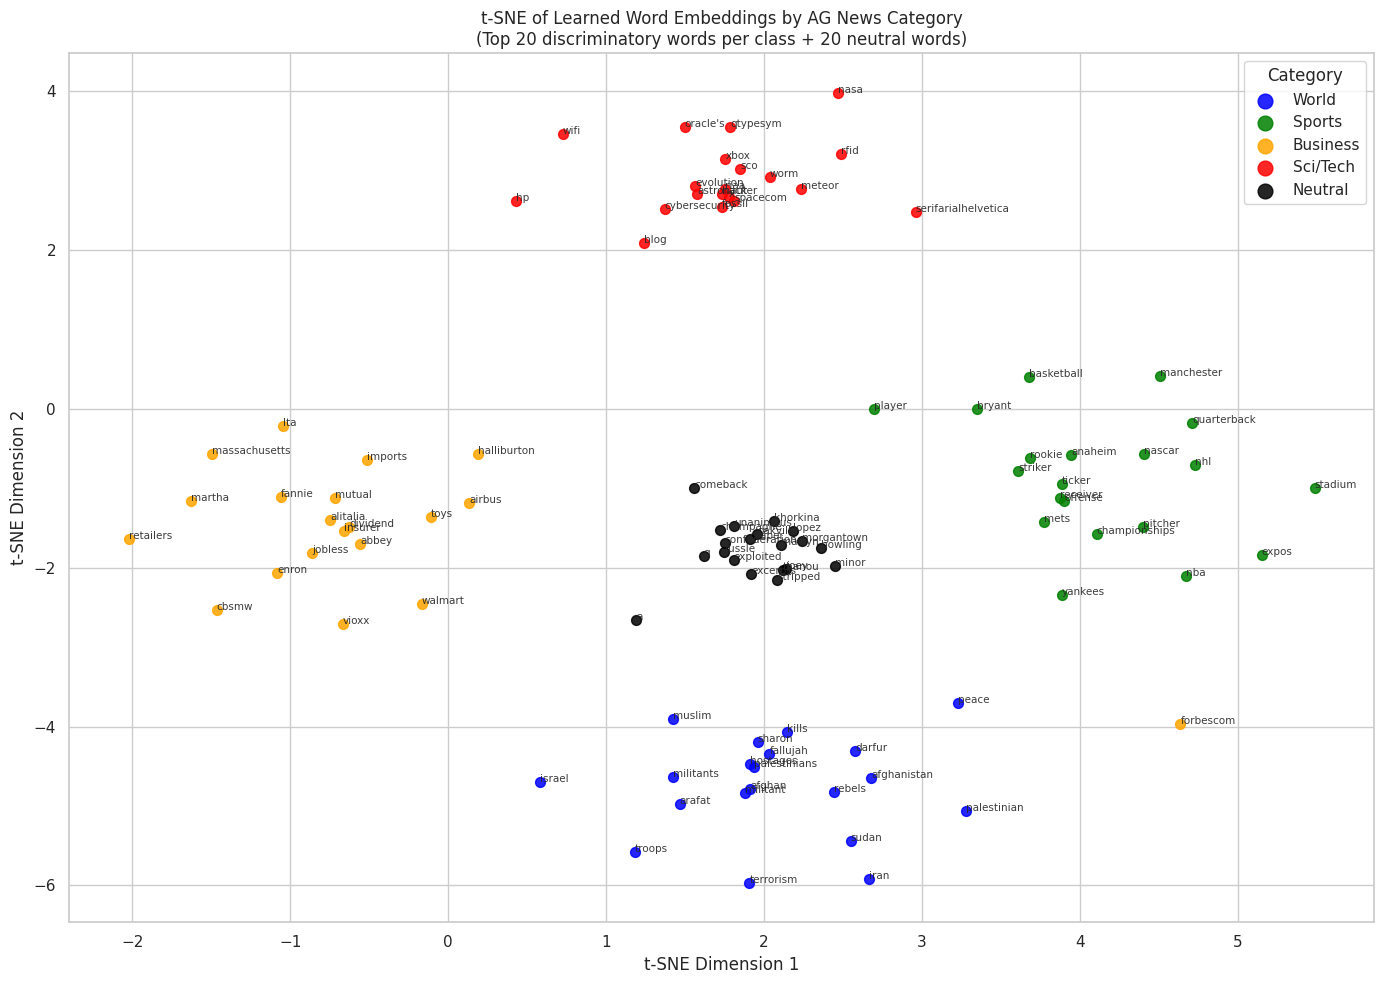

In [55]:

# ANSWER:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch

# Build index-to-word mapping from the vocab dict (word -> idx)
idx_to_word = {v: k for k, v in ag_news_vocab.items()}
vocab_size = len(ag_news_vocab)
device = next(model_cnn.parameters()).device

# ---- Step 1: Score every vocab token via a single-token sequence ----
# Feed each token ID as a length-1 sequence and collect class logits.
model_cnn.eval()
batch_size = 512
all_logits = []
min_len = max(conv.kernel_size[0] for conv in model_cnn.convs)

with torch.no_grad():
    for start in range(0, vocab_size, batch_size):
        end = min(start + batch_size, vocab_size)
        ids = torch.arange(start, end, device=device).unsqueeze(1)  # (batch, 1)
        ids = ids.expand(-1, min_len)                                # (batch, min_len)
        logits = model_cnn(ids)
        all_logits.append(logits.cpu())

all_logits = torch.cat(all_logits, dim=0)  # (vocab_size, 4)
probs = torch.softmax(all_logits, dim=1)   # (vocab_size, 4)

# ---- Step 2: Select top-20 discriminatory words per class ----
# AG News label order: 0=World, 1=Sports, 2=Business, 3=Sci/Tech
category_names = ["World", "Sports", "Business", "Sci/Tech"]
special_indices = {ag_news_vocab.get("<PAD>", 0), ag_news_vocab.get("<UNK>", 1)}

selected_words   = {}
selected_indices = {}
used_indices     = set(special_indices)   # prevent special tokens + duplicates

for cls_idx, cls_name in enumerate(category_names):
    class_probs = probs[:, cls_idx].clone()
    for idx in used_indices:
        class_probs[idx] = -1.0           # mask out already-used entries
    top_indices = class_probs.topk(20).indices.tolist()
    top_words   = [idx_to_word[i] for i in top_indices]
    selected_words[cls_name]   = top_words
    selected_indices[cls_name] = top_indices
    used_indices.update(top_indices)
    print(f"{cls_name}: {top_words}")

# ---- Step 3: Select 20 neutral words (minimal influence on any class) ----
# Words whose max softmax probability is closest to 0.25 (uniform over 4 classes)
# are least discriminatory for any category.
max_prob = probs.max(dim=1).values.clone()
for idx in used_indices:
    max_prob[idx] = 2.0                   # push used / special tokens far away
neutrality_score = (max_prob - 0.25).abs()
neutral_indices  = neutrality_score.topk(20, largest=False).indices.tolist()
neutral_words    = [idx_to_word[i] for i in neutral_indices]
selected_words["Neutral"]   = neutral_words
selected_indices["Neutral"] = neutral_indices
print(f"Neutral: {neutral_words}")

# ---- Step 4: Gather embedding vectors for selected words ----
embedding_weights = model_cnn.embedding.weight.detach().cpu()  # (vocab_size, embed_dim)

all_sel_indices = []
all_sel_words   = []
all_sel_labels  = []

for cat_name in ["World", "Sports", "Business", "Sci/Tech", "Neutral"]:
    for idx, word in zip(selected_indices[cat_name], selected_words[cat_name]):
        all_sel_indices.append(idx)
        all_sel_words.append(word)
        all_sel_labels.append(cat_name)

word_embeddings = embedding_weights[all_sel_indices].numpy()  # (N, embed_dim)

# ---- Step 5: t-SNE dimensionality reduction to 2D ----
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
embeddings_2d = tsne.fit_transform(word_embeddings)

# ---- Step 6: Scatter plot ----
colors_map = {
    "World":    "blue",
    "Sports":   "green",
    "Business": "orange",
    "Sci/Tech": "red",
    "Neutral":  "black",
}

fig, ax = plt.subplots(figsize=(14, 10))
plotted_labels = set()

for i, (word, label) in enumerate(zip(all_sel_words, all_sel_labels)):
    color = colors_map[label]
    lbl   = label if label not in plotted_labels else "_nolegend_"
    ax.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1],
               color=color, s=50, label=lbl, alpha=0.85)
    ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                fontsize=7.5, alpha=0.9)
    plotted_labels.add(label)

ax.legend(title="Category", loc="best", markerscale=1.5)
ax.set_title(
    "t-SNE of Learned Word Embeddings by AG News Category\n"
    "(Top 20 discriminatory words per class + 20 neutral words)"
)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


**Analyze:** 
   - Do words from the same category cluster together? 
   - Are there interesting relationships between categories (e.g., do Business and World overlap)?
   - Do the discriminatory words make semantic sense for their categories? Any surprises?

**ANSWER:**
<br>
Yes, words from the same category cluster together. There does not seem to be much overlap, but we can see that Business and Sports are kind of like opposites in the first dimension while World and Sci/Tech are opposites in the second dimension. I'm a little surprised that forbes[.]com is on the right and far off from the other business words.
<br>

## Challenge 4: Saliency maps on text? Yes, please!

Remember the saliency maps from CNNs? They did a fantastic job in helping us understand what a model was paying attention to. There is no reason why you can't do the same thing for text models. You can create "saliency maps" by computing gradients with respect to input embeddings to see which words/tokens most influence predictions for specific examples. 

**How to create text saliency maps:**
1. Pass an input sequence through your trained model in eval mode
2. Get the predicted class logit (before softmax) for the target class
3. Compute gradients of that logit with respect to the input embeddings: `logit.backward()`
4. The gradient magnitude for each token's embedding indicates its importance
5. Come up with a unique way to visualize what parts of your input your model is paying attention to the most. You could visualize by coloring words based on their gradient magnitude. Use whatever method makes the most sense to you.

Ultimately, your visualization should reveal parts of your input sequence most strongly influenced the model's prediction for that class.

### Your task:
Once you create a method to visualize a saliency map for some instance in the test data, generate a saliency map for a correct guess and incorrect guess for each target class. There are four classes in this dataset, and thus you should be visualizing 8 sentences.

**HINT:** using `from IPython.display import HTML, display` may be your easiest way to apply color to text without having to deal with graphical plots. 


In [56]:

# ANSWER:
import torch
import numpy as np
from IPython.display import HTML, display

device = next(model_cnn.parameters()).device

# ---- Saliency computation ----
def get_saliency(model, token_ids, target_class):
    """Compute per-token saliency as gradient magnitude w.r.t. the embedding output.

    Temporarily enables grad on the embedding weight when it is frozen so that
    the gradient still flows through it for visualization purposes only.
    """
    model.eval()
    x = token_ids.unsqueeze(0).to(device)  # (1, seq_len)

    # If embeddings are frozen, briefly unfreeze so gradients can flow
    was_frozen = not model.embedding.weight.requires_grad
    if was_frozen:
        model.embedding.weight.requires_grad_(True)

    try:
        embedded = model.embedding(x)       # (1, seq_len, embed_dim)
        embedded.retain_grad()

        # Manually replay the TextCNN1D forward from the embedding output
        emb_t = embedded.permute(0, 2, 1)  # (1, embed_dim, seq_len)
        pooled = [
            torch.relu(conv(emb_t)).max(dim=2).values
            for conv in model.convs
        ]
        features = torch.cat(pooled, dim=1)
        logits = model.classifier_head(features)

        logits[0, target_class].backward()

        grad = embedded.grad[0]             # (seq_len, embed_dim)
        saliency = grad.norm(dim=1)         # (seq_len,)  — L2 norm over embed dim
        return saliency.detach().cpu().numpy(), logits.detach().cpu()
    finally:
        if was_frozen:
            model.embedding.weight.requires_grad_(False)


def render_saliency_html(words, saliency, title=""):
    """Return an HTML string with words highlighted by saliency intensity."""
    s_min, s_max = saliency.min(), saliency.max()
    norm = (saliency - s_min) / (s_max - s_min + 1e-8)  # normalise to [0, 1]

    parts = [f'<p style="font-family:monospace; line-height:2;"><b>{title}</b><br>']
    for word, alpha in zip(words, norm):
        color = f"rgba(220, 50, 50, {float(alpha):.2f})"
        parts.append(
            f'<span style="background-color:{color}; padding:2px 4px; '
            f'margin:1px; border-radius:3px;">{word}</span> '
        )
    parts.append("</p>")
    return "".join(parts)


# ---- Find one correct and one incorrect example per class ----
category_names = ["World", "Sports", "Business", "Sci/Tech"]

correct_examples   = {i: None for i in range(4)}
incorrect_examples = {i: None for i in range(4)}

model_cnn.eval()
with torch.no_grad():
    for token_ids, label in test_agnews_dataset:
        lbl = label.item()
        if correct_examples[lbl] is not None and incorrect_examples[lbl] is not None:
            continue
        x = token_ids.unsqueeze(0).to(device)
        pred = model_cnn(x).argmax(dim=1).item()

        if pred == lbl and correct_examples[lbl] is None:
            correct_examples[lbl] = (token_ids, lbl, pred)
        elif pred != lbl and incorrect_examples[lbl] is None:
            incorrect_examples[lbl] = (token_ids, lbl, pred)

        if (all(v is not None for v in correct_examples.values()) and
                all(v is not None for v in incorrect_examples.values())):
            break

# Build idx -> word map (reuse from Challenge 3 if available, else rebuild)
try:
    _ = idx_to_word
except NameError:
    idx_to_word = {v: k for k, v in ag_news_vocab.items()}

# ---- Generate and display all 8 saliency maps ----
html_blocks = [
    "<h3>Text Saliency Maps &mdash; Gradient Magnitude w.r.t. Token Embeddings</h3>",
    "<p>Red intensity = gradient magnitude &rarr; higher influence on the predicted logit.</p>",
]

MAX_TOKENS = 60   # cap displayed length for readability

for cls_idx in range(4):
    cls_name = category_names[cls_idx]
    html_blocks.append(f"<hr><h4>Class {cls_idx}: {cls_name}</h4>")

    for kind, example_dict in [("CORRECT ✓", correct_examples),
                                ("INCORRECT ✗", incorrect_examples)]:
        token_ids, true_lbl, pred_lbl = example_dict[cls_idx]
        words = [idx_to_word.get(tid.item(), "<UNK>") for tid in token_ids]
        # Compute saliency w.r.t. the TRUE class logit
        saliency, logits = get_saliency(model_cnn, token_ids, true_lbl)
        pred_name = category_names[logits.argmax(dim=1).item()]

        title = (f"{kind} &nbsp; true=<b>{cls_name}</b>, "
                 f"predicted=<b>{pred_name}</b>")
        html_blocks.append(
            render_saliency_html(words[:MAX_TOKENS], saliency[:MAX_TOKENS], title)
        )

display(HTML("\n".join(html_blocks)))


## Challenge 5: [ADVANCED!] Word2Vec and the Emergence of Meaning and Context

**Motivation**
In the Lab, you used an Embedding layer to solve a **supervised classification** problem **Sentiment Analysis**. Then, in the previous challenges, you used an Embedding layer to create a **Topic Classifier**. For sentiment analysis, the embeddings learned to group "good" and "great" together simply because both words minimized the loss for the "Positive" label. But what if we don't have human-provided labels? How do massive models like GPT-4 or LLaMA learn the intrinsic, general meaning of the English language? The answer is **Self-Supervised Learning (SSL)**. 

**Self-Supervised Learning (SSL)** is a paradigm where a model learns meaningful representations from unlabeled data. It's not **unsupervised learning** where there are no labels for your data. Instead of relying on human-annotated labels, SSL formulates a "pretext task" where the data itself provides the labels. We essentially create our own supervisory signal. For example, predicting missing words in a sentence, reconstructing corrupted images, or forecasting the next frame in a video. The key insight is that solving these artificial tasks forces the model to learn rich, generalizable features about the underlying structure of the data—features that transfer well to downstream supervised tasks.

In this challenge, you will build a foundational Word2Vec model from scratch using the **Skip-Gram** architecture. Your objective is to engineer a "fake task" where the dataset provides its own labels. Our task is to *predict the surrounding context words given a center word*. Let's break this down:

**What Skip-Gram predicts**

- You have a **center word** and a **context window** (e.g. 2 words to the left, 2 to the right).
- For each center word, you form **several** (center, context) pairs: one for each context word in that window.
- The task is: **given the center word, predict which word was observed as context** (any one of the words in the window — left or right, not necessarily “next”).

So the model is answering: “Given this center word, one of the words that appeared near it was **this** context word.” It’s a classification over the whole vocabulary: “which word was this context word?”

By forcing the network through a narrow embedding bottleneck to solve this massive vocabulary classification problem, the intermediate weights will magically organize themselves into a semantic map of the English language. 

**Example**

- Sentence: `“Apple released new software today.”`
- Center `“new”` with window 2 gives **four** targets: `“apple”`, `“released”`, `“software”`, “`today”`.
- So you get four training examples:
  - center `“new”` → predict `“apple”`
  - center `“new”` → predict `“released”`
  - center `“new”` → predict `“software”`
  - center `“new”` → predict `“today”`

So the model is predicting **a context word** (one of the neighbors in the window), not specifically “the next” or “the previous” word. That’s why your data pipeline generates **many** (center_id, context_id) pairs per sentence: each pair is one such prediction task.

> **Why This Matters for LLMs:** Every modern language model, from GPT-4 to LLaMA to Claude, begins its journey by learning embeddings through **self-supervised learning!** The Skip-Gram task you'll implement here is the conceptual ancestor of the pretraining objectives used in **transformers**. By building Word2Vec from scratch, you'll understand the fundamental principle that powers all LLMs: **meaning emerges from predicting context**. This same insight, scaled up with billions of parameters and trillions of tokens, is what enables ChatGPT to write essays, code, and poetry. You're about to build the foundation of that magic.

### Task 1: Preparing our data pipeline
We will use the same AG News dataset and tokenization approach as in Challenge 2. However, to keep training times reasonable, let's read in the data, using a min_freq of 3, and then subset to the first 15,000 articles.

1. Add the ability to subset the data by passing `train_subset_fn` and `test_subset_fn` parameters to `get_hf_text_dataset` in `data.py`. These parameters can serve to map or filter input data. (See Step 2 for an example). In your `get_hf_text_dataset` function, you'll add something like the following:

```python
     ds = load_dataset(hf_name)
    train_data = ds[train_split]
    test_data = ds[test_split]
    
    # Apply subset function if provided
    if subset_fn is not None:
        train_data = train_subset_fn(train_data)
        test_data = test_subset_fn(test_data)
```

2. **Load the data** using `get_hf_text_dataset` with a `min_freq=3` and `max_vocab_size=25000`. Use your new subset function parameters to subset to the first 15,000 training articles. Keep in mind that our function already create lowercases and tokenizes the text read in, and generates a vocabulary dictionary. It'll only tokenize and encode the text read in after the subset function maps or filters the data, not the entire dataset.
You won't need the test dataset returned for this challenge.
```python
train_agnews_dataset, _, ag_news_vocab = get_hf_text_dataset(
    "ag_news",
    max_vocab_size=25000,
    min_freq=3,
    train_subset_fn=lambda ds: ds.select(range(15000))
)
```
3. **Generate Skip-Gram Pairs:** Implement a *sliding-window* function that, given encoded token-ID sequences, yields `(center_id, context_id)` pairs with `window_size=2`. For every center word in a sentence, generate a pair for each of the 2 words to its left and the 2 to its right.
    * *Example:* Using our example, center "new" yields pairs: `("new", "apple")`, `("new", "released")`, `("new", "software")`, `("new", "today")` as integer IDs. (Remember, we are using integer IDs, not the actual words.)


4. **DataLoader:** Wrap the pairs in a PyTorch `TensorDataset` e.g. `TensorDataset(centers_tensor, contexts_tensor)`.  optionally split train/val, and create DataLoaders with **`get_dataloaders`** from `my_engine.data`.


In [ ]:
# TASK 1
from lantern.text import generate_skip_gram_pairs
from lantern.data import get_hf_text_dataset, get_dataloaders
from torch.utils.data import random_split

train_agnews_dataset, _, ag_news_vocab = get_hf_text_dataset(
    "ag_news",
    max_vocab_size=25000,
    min_freq=3,
    train_subset_fn=lambda ds: ds.select(range(15000))
)
print(f"Dataset size: {len(train_agnews_dataset)}")
print(f"Vocab size: {len(ag_news_vocab)}")
print(f"Sample entry: {train_agnews_dataset[0]}")

skip_gram_pairs = generate_skip_gram_pairs(train_agnews_dataset, window_size=2)
n = len(skip_gram_pairs)
print(f"\nTotal skip-gram pairs: {n}")
print(f"Sample skip-gram pair: {skip_gram_pairs[0]}")  # should be (center, context) word indices

# Does not matter what we put for eval dataset since we are not strictly evaluating on it (accuracy irrelevant)
skip_gram_train_loader, skip_gram_test_loader = get_dataloaders(skip_gram_pairs, skip_gram_pairs, train_batch_size=256, eval_batch_size=512)
print(f"\nTrain batches: {len(skip_gram_train_loader)}")
print(f"Test batches:  {len(skip_gram_test_loader)}")

# Inspect one batch to confirm shapes
batch = next(iter(skip_gram_train_loader))
print(f"\nSample batch type: {type(batch)}")
print(f"Sample batch: {batch}")  # expecting two tensors: centers, contexts

Dataset size: 15000
Vocab size: 14121
Sample entry: (tensor([ 374, 1185, 2179, 7213,  121,   57,    2, 1459,   17,   17,    1,  374,
        6171,    1,    5,    1,   35, 3958, 1239,  334]), tensor(2))

Total skip-gram pairs: 2042276
Sample skip-gram pair: (tensor(2179), tensor(374))

Train batches: 7978
Test batches:  3989

Sample batch type: <class 'list'>
Sample batch: [tensor([  449,     5,     1,     4,   863,    94,     3,     2,  5789,  2161,
          118,    22,   878,    14,  3966,    65,   333,    29,    61,  4480,
           33,   983,    10,   154,     4,  1783,     6,     1,    24,   667,
           48,  2049,  1283,     2,     5,  3912,  1596,     4,     3,  1809,
           83,  9045,     2,   159,    78,    17,   198,  2101,     2,    27,
         1465,   351,  6100,   493,   163,   591,  5140,   305,   102,    93,
         1232,   112,  2788,     2,  4545,  4914,     1,  1489,     5,  1391,
            4,  4857,  1542,    62, 13040,    15,    71,   121,   944,     9,


### Task 2: The Skip-Gram Architecture
Define a PyTorch `nn.Module` with exactly two layers:
1. **The Representation Layer:** An `nn.Embedding(vocab_size, embedding_dim)` (e.g. `embedding_dim=64`).
2. **The Prediction Layer:** An `nn.Linear(embedding_dim, vocab_size)`.

Give the module a **`num_outputs`** attribute (set to `vocab_size`) so the course **Trainer** can infer the number of classes for logging.

*Engineering Note:* This model takes a center word ID (or batch of IDs), retrieves dense vectors, and outputs raw logits over the entire vocabulary. Production systems use "Negative Sampling"; our naive classification approach works for this subset.

### Task 3: The Training Loop
You have a model! Use **`nn.CrossEntropyLoss()`**, the course **`Trainer`**, **`make_optimizer`**, and **`TrainerConfig`**. Pass a Weights. Train for 5 to 10 epochs. 

> Yes, you can use your Trainer engine with any arbitrary PyTorch model, including the `skipgram_model` created in the previous step! It need not be something hooked into our entire pipeline!

**Expect LOW ACCURACY!**<br>
Accuracy will look low even when the model is learning well. Why? The model does **multi-class classification over the whole vocabulary**: given a center word, it predicts one of `vocab_size` context words.
- **Random guess:** accuracy ≈ `1 / vocab_size`.
  - With ~10k words → ~0.01%
  - With ~25k words → ~0.004%
- So the **random baseline** is already tiny.

**What’s typical**

- With **full softmax** over the whole vocabulary (no negative sampling), accuracy usually stays in the **low single digits**, sometimes as low as **1–5%** depending on:
  - vocabulary size,
  - amount of data,
  - epochs and learning rate.
- So **1%–5%** is a very good “typical” range; and keep in mind, even if you are sub **1%**, you are already doing far better than random guessing! It is a strong sign the model is learning something.

**Why the embeddings can still be good with such low accuracy**

- The **training objective** is to push the embedding space so that center and context words are close. The model can do that well even when **accuracy** is low, because:
  - there are thousands of wrong answers and only one correct one per example, and
  - the metric is very strict (exact word match).
- So in Task 3, **don’t expect high accuracy**. Low single-digit (or even sub‑1%) accuracy is normal; the real check is Task 4: whether similar words (e.g. “baseball”, “software”) get sensible neighbors.

In [58]:
from lantern.config import TrainerConfig, MetricsConfig, ModelConfig, ModelType
from lantern.utils import make_optimizer, build_model
from lantern.trainer import Trainer

# TASK 3

if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 5
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 1
else:
    num_epochs = 0


# Setup your TrainerConfig and ModelConfig
trainer_config = TrainerConfig(
    trainer_batch_size=256,
    evaluator_batch_size=512,
    learning_rate=1e-3,
    optimizer_name="adam", 
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
    early_stopping_patience=None
)
config_skip = ModelConfig(
    model_type=ModelType.SKIPGRAM,
    vocab_size=len(ag_news_vocab),
    embedding_dim=64,
)

skipgram_model = build_model(input_spec=0, num_outputs=0, config=config_skip)
# Get your dataloaders

run = None
if DO_WANDB_LOGGING:
    run = wandb.init(
        project="csci357-hw08-chal05",
        entity=entity,
        name=f"{user_initials}-skipgram",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )
optimizer = make_optimizer(skipgram_model.parameters(), trainer_config)
# Instantiate a Trainer and call trainer.fit(). Remember, this is a multi-class classification problem, so you want "accuracy" and "f1" as metrics.
with Trainer(
    model=skipgram_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=run,
    wandb_watch=False
) as trainer:
    results = trainer.fit(skip_gram_train_loader, skip_gram_test_loader)

print(f"\nResults: {results}")





Epoch 0:
Train Accuracy=0.08%  Val Accuracy=0.12%
Train Loss=7.3618  Val Loss=6.8867
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=0.13%  Val Accuracy=0.16%
Train Loss=6.8634  Val Loss=6.7396
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=0.17%  Val Accuracy=0.19%
Train Loss=6.7523  Val Loss=6.6575
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=0.20%  Val Accuracy=0.22%
Train Loss=6.6866  Val Loss=6.6055
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt


wandb: WARNING SkipGram(vocab_size=14121, embedding_dim=64) model has not been watched


Epoch 4:
Train Accuracy=0.22%  Val Accuracy=0.22%
Train Loss=6.6440  Val Loss=6.5699
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
--> Saving checkpoint: ./checkpoints/last.pt

Results: {'num_epochs': 5, 'train_accuracy': 0.002214288804680109, 'val_accuracy': 0.0022430778481066227, 'train_loss': 6.644012770708592, 'val_loss': 6.569894360457532}


### Task 4: Semantic Extraction & Evaluation
Once training is complete, the `nn.Linear` layer has served its purpose as our "proxy task" mechanism. **Throw it away.** The real prize is the `embedding.weight.data` tensor inside the first layer!

> We're going to extract "similar words" in the embedding space. So, for this problem, we're identifying words that have some contextual similarity, not similar meaning. They are words that would appear around the given words.

Write a function `print_similar_words(embedding_layer, vocab, target_word, k=5)` whose job is to print the k most similar words to a target word using cosine similarity applied to the learned word embeddings.

Steps to implement:
1. Retrieve the index of `target_word` from the `vocab` dictionary. If not in vocab, print an informative message and exit the function.
2. Extract the embedding vector for the target word from `embedding_layer.weight`, making sure its shape is compatible for similarity computation.
3. Compute cosine similarity between the target word vector and all other word vectors in the embedding matrix (use `torch.nn.functional.cosine_similarity`, dimension=1).
4. Identify the k+1 highest similarity scores and their indices with `torch.topk` (k+1 because the target word will have highest similarity to itself).
5. Map indices back to words via an inverted vocab dictionary.
6. Print out the k words with the highest cosine similarity, skipping the target word itself, formatted with their similarity scores.
7. Make sure to handle edge cases, such as when vocab is smaller than k.

Test your AI's understanding of the world by querying words like `"software"`, `"baseball"`, `"stock"`, and `"government"`.

In [59]:
# TASK 4

def print_similar_words(embedding_layer, vocab, target_word, k=5):
    """print the k most similar words to a target word using cosine similarity.
    
    Args:
        embedding_layer: The embedding layer containing word vectors.
        vocab: Dictionary mapping words to integer indices.
        target_word: The word to find similar words for.
        k: Number of similar words to return. Defaults to 5.
    
    Returns:
        None. Prints the top-k most similar words and their cosine similarity scores.
    """
    if target_word not in vocab:
        print(f"'{target_word}' not in vocabulary")
        return

    # Build a reverse mapping from index to word
    itos = {idx: word for word, idx in vocab.items()}

    # Retrieve the full embedding weight matrix (vocab_size, embed_dim)
    weights = embedding_layer.weight.data

    # Look up the target word's vector and add a batch dimension
    target_idx = vocab[target_word]
    query_vec = weights[target_idx].unsqueeze(0)  # (1, embed_dim)

    # Compute cosine similarity between query and all embeddings
    sims = cosine_similarity(query_vec, weights)  # (vocab_size,)

    # Mask out the query word so it doesn't appear in results
    sims[target_idx] = -1.0

    # Get top-k results
    top_scores, top_indices = torch.topk(sims, k=k)

    print(f"Words most similar to '{target_word}':")
    for score, idx in zip(top_scores, top_indices):
        print(f"  {itos.get(idx.item(), '<UNK>'):<15} {score.item():.4f}")


print_similar_words(skipgram_model.embedding, ag_news_vocab, "software", 5)
print_similar_words(skipgram_model.embedding, ag_news_vocab, "baseball", 5)
print_similar_words(skipgram_model.embedding, ag_news_vocab, "stock", 5)
print_similar_words(skipgram_model.embedding, ag_news_vocab, "government", 5)

Words most similar to 'software':
  content         0.6885
  tools           0.6765
  postpones       0.6721
  vendor          0.6572
  developer       0.6393
Words most similar to 'baseball':
  racing          0.7321
  english         0.6786
  tavarez's       0.6754
  matches         0.6559
  scottish        0.6535
Words most similar to 'stock':
  unemployment    0.6591
  founders        0.6381
  advisor         0.6303
  auctionstyle    0.6197
  muchhyped       0.6099
Words most similar to 'government':
  arabia          0.5115
  army            0.4961
  ministry        0.4895
  humanitarian    0.4716
  mdc             0.4669


In [ ]:
show_section()

# Career Survey

Word embeddings are no longer just a research concept — they are a **product**. Companies like OpenAI, Cohere, and Google offer embedding APIs that convert text into vectors, and an ecosystem of **vector databases** (Pinecone, Weaviate, Chroma, Qdrant) has emerged to store and search these vectors at scale. Embeddings are powerful. They are an integral part of the best NLP tasks, as well as transformers and LLMs. More recently, they are a critical part of infrastructure behind **Retrieval‑Augmented Generation (RAG)**, a leading architecture for building practical LLM applications in 2026.

**Essay Prompts**  
Answer each prompt in 1-2 paragraphs:

1. **What Is RAG and Why Use It?**  
   Research and, in your own words, explain what **Retrieval‑Augmented Generation (RAG)** is. This has become a pretty hot area to know about in the AI career landscape. Describe the basic idea of how it works at a high level: how a system first looks up relevant information from a collection of documents and then uses an LLM to generate an answer based on that information. Finally, briefly explain one reason why this approach is useful compared to using an LLM “by itself” with no external information. 

**ANSWER:**
<br>
RAG is a system that augments to LLM response generation by taking a query, embedding it and then using those embeddings to find documents that are relevant to the query based on cosine similarity scores. The document is then passed onto the LLM, which is then added onto the query as additional context. This is more useful than just using an LLM "by itself" because it has access to more context that it can use to generate more relevant answers.
<br>




2. **Embeddings, Vector Databases, and the R in RAG**  
   Research how embeddings and vector databases are used inside a RAG system. You've learned about embeddings. Explain how text is turned into vectors (embeddings) and stored in a vector database, and how a user’s question is also turned into a vector so the system can find the most similar pieces of text. Then, in 1–2 sentences, describe why a similarity measure like cosine similarity is important for deciding which pieces of text to send to the LLM. 

**ANSWER:**
<br>
The text is first broken down into tokens. Then, the tokens are passed through an embedding model like OpenAI's text-embedding-ada-002. This creates a vector that can then be stored in a vector database. A query that is tokenized and transformed into a vector can be used to find the document containing the most relevant context. A similarity measure like cosine similarity is important in deciding which pieces of text to send to LLMs because it measures how similar two different samples of text are to each other in the embedding dimensions. The closer the values, the more similar their content is, which gives more context to the LLM.
<br>





In [ ]:
show_section()

# Society

The embeddings you explored this week encode more than just word meaning — they also encode the **biases** present in the training data. In 2016, Bolukbasi et al. published a landmark paper titled *“Man is to Computer Programmer as Woman is to Homemaker: Debiasing Word Embeddings”* that demonstrated alarming gender stereotypes encoded in Word2Vec and GloVe vectors. The same analogy structure that gives us `king - man + woman = queen` also produces results like `computer_programmer - man + woman = homemaker`. [2016, Bolukbasi et al](https://arxiv.org/abs/1607.06520)

These biases are not abstract — they propagate into downstream systems. A resume screening tool using biased embeddings might systematically rank male candidates higher for technical roles, and a translation system might default to gendered pronouns based on occupation stereotypes. Because embeddings are trained on text from the internet, they inherit the biases of that text: racial, gender, religious, and cultural. Embeddings and related NLP models are also being used in **high‑stakes decision systems** such as hiring filters, criminal risk assessment tools, loan approval models, and large‑scale content moderation. 

**Essay Prompts**

Write **1–2 paragraphs for each question**.  


1. **Gender Bias in Embeddings**<br><br>
Use the analogy function from Section 3 to test for gender bias in GloVe. You can test out various analogies up above. At a high level, research the Bolukbasi et al. (2016) paper: what method did they propose for debiasing (for example, identifying a “gender direction” in the vector space and then “neutralizing” or “equalizing” certain words), and what are its limitations? Reflect on whether this kind of mathematical debiasing is sufficient on its own, or whether there are deeper issues about data, society, and system design that it cannot fix. 

**ANSWER:**
<br>
Bolukbasi et al. (2016) demonstrated that word embeddings encode real-world gender stereotypes, observable through analogies like man is to programmer as woman is to homemaker. Their debiasing method first identifies a "gender direction" in the vector space using PCA on known gender pairs (he – she, man – woman, etc.), then applies two operations: neutralization, which strips the gender component from words that should be neutral (like doctor), and equalization, which ensures legitimate gender pairs like actor/actress differ only along the gender axis. The method also assumes a strict male/female binary and requires subjective manual curation of which words to neutralize.

More fundamentally, mathematical debiasing cannot fix what is a societal problem masquerading as a linear algebra one. Embeddings are trained on text produced by a world shaped by historical inequities, so they are faithfully reflecting real patterns in language, not inventing them. Downstream models fine-tuned on biased data will re-acquire bias regardless of how clean the embedding layer is, and real systems like resume screeners and machine translation tools continue to exhibit gender bias even after formal debiasing. The approach is a meaningful first step in making bias  tractable, but it is no substitute for diverse training data, rigorous auditing of deployed systems, and structural attention to who is harmed when these systems fail.
<br>



2. **Embeddings in High‑Stakes Decisions**<br><br>
Embeddings and related NLP representations are used in systems that affect people’s lives: hiring tools, criminal risk assessment, loan applications, and content moderation, among others. Choose one of these domains (or a domain of interest to you) and research a documented case where NLP or ML model bias from word embeddings or similar text representations caused harm or clear unfairness. What happened, and who was impacted? What could have been done differently at the level of data collection, model/embedding design, evaluation, or deployment? Discuss who you think bears the primary responsibility — the embedding/model creators, the system builders who integrated them, or the organizations that deployed the systems — and why. 
   
**ANSWER:**
<br>
A well-documented case of NLP-driven harm in hiring is Amazon's automated resume screening tool, which the company quietly built and then abandoned in 2018. The tool had been trained on historic CVs submitted to the company, which disproportionately came from men. As a result, it learned that male-related words were more associated with technology and employment-related words than female-related words were. In practice, this meant the system penalized resumes that included words like "women" as in "Society of Women Engineers" and downgraded graduates of all-women's colleges. The people most directly harmed were women applying for technical roles, who were being filtered out before a human ever saw their application. Several interventions could have changed the outcome: training data could have been audited and rebalanced to correct for the historical underrepresentation of women in tech submissions; the model could have been evaluated explicitly for disparate impact across gender before deployment; and the organization could have required human review for any candidate the system flagged for rejection, rather than letting the algorithm act as a gatekeeper.

On the question of responsibility, the clearest answer is that it is layered, but the heaviest burden falls on Amazon as the deploying organization. As long as language data used to train NLP models contain biases, word embeddings will keep replicating historical injustices in downstream applications unless effective regulatory practices are implemented to deal with bias. Embedding creators are responsible for documenting these known limitations clearly. System builders who integrate embeddings into high-stakes pipelines bear responsibility for conducting fairness audits before shipping. But Amazon, the organization that commissioned the tool, controlled the training data, chose to deploy it in real hiring decisions. Not only did they have the most to gain or lose from its outcomes, but they also had both the most power and the most obligation to catch this before it caused harm. The fact that the system was used quietly for years before being scrapped suggests the failure was not just technical but organizational: nobody with authority over the deployment asked the right questions about who might be disadvantaged by it.

[source](https://www.reuters.com/article/world/insight-amazon-scraps-secret-ai-recruiting-tool-that-showed-bias-against-women-idUSKCN1MK0AG/)
<br>

# AI Usage Disclosure

**IDE or browser-based environment used:** VSCode

**AI tools used:** Claude

**Short reflection:**
How did you use AI this week? Did it help you understand embeddings, tokenization, or the text classification pipeline? Did it help debug your engine extensions? Be specific about what worked well and what didn't.

Yes, I used Claude for a few explanations and code syntax.

**AI Chat Dialogs:**
(Paste relevant snippets here - particularly any that helped you understand conceptual questions or debug code)

<br/>
1.

```
How do I build the one-hot matrix for this:

# DONE: Create an Embedding layer with a vocabulary of 6 and 4 dimensions
small_emb = nn.Embedding(num_embeddings=6, embedding_dim=4)

# DONE: Show the weight data 
print("Embedding weight matrix (6 words, 4 dimensions):")
print(small_emb.weight.data)

# DONE: Create a tensor of indices to look up in the embedding layer. Use indices 0, 3, and 5.
indices = torch.tensor([0,3,5])
# DONE: Pass the indices through the embedding layer to get the corresponding vectors
output = small_emb(indices)

print(f"\nLookup indices {indices.tolist()} -> shape {output.shape}")
print(output)

# DONE: Create one-hot encoded vector for the indices (shape: [3, 6])
one_hot = torch.
# Manually perform the lookup by matrix multiplication with the embedding weight matrix
manual_lookup = one_hot @ small_emb.weight

You need torch.zeros and scatter_ to build the one-hot matrix:
pythonone_hot = torch.zeros(3, 6)
one_hot.scatter_(1, indices.unsqueeze(1), 1.0)
```

2.
```
The slowness comes from two compounding factors:                                                                                                                                              
                                                                                                                                                                                                
  1. Massive dataset size                                                                                                                                                                     
  15,000 AG News articles × ~200 tokens each × 4 pairs per token (window_size=2) ≈ ~12 million skip-gram pairs. At the default batch_size=64 used in cell 143, that's ~150,000 batches per      
  epoch.                                                                                                                                                                                        
                                                                                                                                                                                                
  2. Expensive 25,000-class softmax                                                                                                                                                             
  The nn.Linear(64, 25000) prediction layer forces CrossEntropyLoss to compute a full softmax over 25k vocabulary items on every single sample. This is the classic Skip-Gram bottleneck — real
  Word2Vec implementations avoid it using negative sampling instead.                                                                                                                            
                                                                                                                                                                                              
  The most actionable fix is in cell 143: get_dataloaders is called without explicit batch sizes, so it falls back to the default of 64. You should pass much larger batch sizes:               
                                                                                                                                                                                              
  skip_gram_train_loader, skip_gram_test_loader = get_dataloaders(                                                                                                                              
      train_ds, test_ds,                                                                                                                                                                        
      train_batch_size=512,                                                                                                                                                                     
      eval_batch_size=1024                                                                                                                                                                      
  )                                                                                                                                                                                             
                                                                                                                                                                                              
  This alone would reduce iterations per epoch by ~8x. You could also reduce max_vocab_size for this task — Skip-Gram doesn't need the full 25k vocab. Something like 10,000 would cut the      
  Linear layer size in half.                                                                                                                                                                  
                                                                                                                                                                                                
  Nothing is broken — these are just the expected costs of vanilla Skip-Gram with full softmax at this scale. The notebook even warns "training times" will be significant.    
```


# Clean shutdown for Colab

In [54]:
if IN_COLAB:
    from google.colab import runtime
    print("Disconnecting runtime...")
    runtime.unassign()
else:
    print("Not running in Colab, skipping disconnect.")

Disconnecting runtime...
